<a href="https://colab.research.google.com/github/dakshini01/ProdFusion/blob/main/codes/04_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Validation v2 — Exact Bayesian Model C + Kalman DLM

This Colab notebook upgrades `validation (1).ipynb` with the strongest **evaluation and reporting ideas** from `05_bayesian_kalman_paper_validation_corrected (1).ipynb`.

## Validation contract

- The garment Bayesian model is **never refitted or replaced** in this notebook.
- The exact authoritative Model C artifacts are loaded from:
  - `bayesian/02_model_C_final_logwip_monotone.nc`
  - `models/02_model_C_posterior_predictions.npz`
  - `models/02_model_C_artifact_metadata.json`
- The exact saved Model C split indices and posterior predictive draws are reused.
- Notebook 05's alternative Bayesian fit and its residual-correction construction are **not imported**.
- The paper-style comparison uses Model C's exact random holdout.
- The corrected Kalman DLM is evaluated separately on its future temporal holdout.
- A Bayesian + Kalman score is reported only on the **dual-holdout intersection**, where rows are out-of-sample for both components.
- The paper's tree-ensemble and GBT+SMOTE results are published benchmarks only; those models are not retrained.
- No SMOTE is used by Model C. Probability calibration and cost-sensitive decisions are evaluated directly.
- Generated CSV, Markdown, JSON, and image outputs are written to `output/validation/`.

## Upgrades adopted from Notebook 05

1. Explicit paper-vs-project comparison tables.
2. Specificity, ECE, false-positive/false-negative counts, and expected decision cost.
3. Separate default and cost-sensitive confusion matrices.
4. ROC, precision-recall, and calibration panels with prevalence reference.
5. A conditional exact-Model-C incentive contrast from 0 to 69.5 BDT.
6. Posterior uncertainty for actionable incentive thresholds.
7. Scenario-level expected productivity and low-class probability plots.
8. A clearer protocol/results summary and migration audit.

## Main coverage

1. Artifact integrity and leakage checks.
2. Exact Model C regression and posterior predictive validation.
3. Paper-compatible 3-class and 2-class classification.
4. Driver, interaction, and 69.5-BDT rule validation.
5. What-if, team heterogeneity, thresholds, missing-WIP sensitivity, and budget allocation.
6. Corrected Kalman future forecasting, uncertainty, calendar effects, and style-change drift.
7. Honest dual-holdout Bayesian + Kalman comparison.
8. A scope marker for SECOM; the Notebook 05 upgrade itself contains no SECOM implementation.


## 0. Install dependencies

In [1]:
# Install only missing/project-specific packages. Avoid forcing incompatible
# pandas/numpy upgrades in Colab.
!pip -q install "pymc>=5.20,<6" "arviz>=0.20,<0.23" netCDF4 ucimlrepo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.8 MB/s eta 0:00:00


## 1. Imports and configuration

In [2]:
%matplotlib inline

import hashlib
import json
import math
import os
import pickle
import shutil
import stat
import subprocess
import textwrap
import warnings
from getpass import getpass
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from IPython.display import Markdown, display
from scipy import stats
from scipy.interpolate import BSpline
from scipy.special import betainc, expit, logit
from sklearn.calibration import calibration_curve
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_curve,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)

RANDOM_SEED = 1234
rng = np.random.default_rng(RANDOM_SEED)

# Paper-compatible achievement classes.
LOW_ACHIEVEMENT = 0.85
NORMAL_ACHIEVEMENT = 0.95
CLASS_NAMES_3 = {0: "Low", 1: "Moderate", 2: "Normal"}

# Published paper reference values. These are not recomputed here.
PAPER_3CLASS = {
    "model": "Tree ensemble (no SMOTE)",
    "accuracy": 0.8389,
    "low_precision": 0.84,
    "low_recall": 0.99,
    "low_f1": 0.91,
}
PAPER_2CLASS = {
    "model": "GBT + SMOTE",
    "accuracy": 0.8639,
    "auc": 0.90,
    "low_precision": 0.93,
    "low_recall": 0.88,
    "low_f1": 0.91,
}
PAPER_INCENTIVE_THRESHOLD = 69.5

# Missing a low day is treated as twice as costly as a false alarm.
FALSE_NEGATIVE_COST = 2.0
FALSE_POSITIVE_COST = 1.0
COST_THRESHOLD = FALSE_POSITIVE_COST / (
    FALSE_NEGATIVE_COST + FALSE_POSITIVE_COST
)

RISK_TARGET = 0.20
MAX_POSTERIOR_DRAWS = 1000
BOOTSTRAP_REPS = 1000
RUN_SECOM = True
SECOM_ADVI_STEPS = 12000
SECOM_POSTERIOR_DRAWS = 1000

print("PyMC:", pm.__version__)
print("Cost-sensitive probability threshold:", round(COST_THRESHOLD, 3))

PyMC: 5.28.5
Cost-sensitive probability threshold: 0.333


## 2. Clone or update the GitHub repository

In [3]:
REPO_URL = "https://github.com/dakshini01/ProdFusion.git"
REPO_NAME = "ProdFusion"

try:
    import google.colab  # type: ignore
    IN_COLAB = True
    BASE_DIR = Path("/content")
except ImportError:
    IN_COLAB = False
    BASE_DIR = Path.cwd()

REPO_DIR = BASE_DIR / REPO_NAME
MODEL_DIR = REPO_DIR / "models"
BAYES_DIR = REPO_DIR / "bayesian"
OUTPUT_DIR = REPO_DIR / "output" / "validation"
CODES_DIR = REPO_DIR / "codes"


def run_cmd(args, cwd=None, check=True, env=None):
    result = subprocess.run(
        args,
        cwd=cwd,
        text=True,
        capture_output=True,
        env=env,
    )
    if result.stdout.strip():
        print(result.stdout.strip())
    if result.stderr.strip() and result.returncode != 0:
        print(result.stderr.strip())
    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed ({result.returncode}): {' '.join(args)}")
    return result


if (REPO_DIR / ".git").exists():
    run_cmd(["git", "-C", str(REPO_DIR), "pull", "--ff-only"], check=False)
else:
    if REPO_DIR.exists():
        shutil.rmtree(REPO_DIR)
    result = run_cmd(["git", "clone", REPO_URL, str(REPO_DIR)], check=False)
    if result.returncode != 0:
        print("Public clone failed. Enter a GitHub token only if access requires it.")
        token = getpass("GitHub token: ").strip()
        if not token:
            raise RuntimeError("Repository clone failed and no token was supplied.")
        env = os.environ.copy()
        env["GITHUB_TOKEN"] = token
        askpass = BASE_DIR / ".git_askpass_validation.sh"
        askpass.write_text(
            "#!/bin/sh\n"
            "case \"$1\" in\n"
            "  *Username*) echo x-access-token ;;\n"
            "  *Password*) echo \"$GITHUB_TOKEN\" ;;\n"
            "esac\n"
        )
        askpass.chmod(askpass.stat().st_mode | stat.S_IXUSR)
        env["GIT_ASKPASS"] = str(askpass)
        env["GIT_TERMINAL_PROMPT"] = "0"
        try:
            run_cmd(["git", "clone", REPO_URL, str(REPO_DIR)], env=env)
        finally:
            token = ""
            env.pop("GITHUB_TOKEN", None)
            askpass.unlink(missing_ok=True)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
BAYES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CODES_DIR.mkdir(parents=True, exist_ok=True)

print("Repository:", REPO_DIR)
print("Validation outputs:", OUTPUT_DIR)

Repository: /content/ProdFusion
Validation outputs: /content/ProdFusion/output/validation


## 3. Locate and verify the exact Model C and Kalman artifacts

In [4]:
METADATA_PATH = MODEL_DIR / "02_model_C_artifact_metadata.json"
PREDICTION_PATH = MODEL_DIR / "02_model_C_posterior_predictions.npz"
POSTERIOR_PATH = BAYES_DIR / "02_model_C_final_logwip_monotone.nc"
MODEL_C_TEST_TABLE_PATH = MODEL_DIR / "02_model_c_test_predictions.csv"
LOO_PATH = MODEL_DIR / "02_loo_comparison.csv"

required = [METADATA_PATH, PREDICTION_PATH, POSTERIOR_PATH]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Required authoritative Model C artifacts are missing. Run "
        "02_bayesian_beta_model.ipynb through its artifact-save and Git-push cells.\n"
        + "\n".join(missing)
    )

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

if metadata.get("model_name") != "Model_C_final_logwip_monotone":
    raise ValueError(
        "The metadata does not describe the required exact Model C: "
        f"{metadata.get('model_name')}"
    )

DATA_PATH = REPO_DIR / metadata["dataset_file"]
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Metadata dataset file does not exist: {DATA_PATH}")

with open(DATA_PATH, "rb") as f:
    actual_hash = hashlib.sha256(f.read()).hexdigest()

expected_hash = metadata.get("dataset_sha256")
if expected_hash and actual_hash != expected_hash:
    raise RuntimeError(
        "Dataset SHA256 does not match the data used to fit Model C. "
        "Do not continue with mismatched data.\n"
        f"Expected: {expected_hash}\nActual:   {actual_hash}"
    )

# Only the authoritative corrected Kalman file is accepted.
# Do not silently fall back to the older incompatible dlm_forecasts.csv.
authoritative_kalman_path = MODEL_DIR / "03_v7_1_forecasts.csv"
KALMAN_FORECAST_PATH = (
    authoritative_kalman_path
    if authoritative_kalman_path.exists()
    else None
)

print("Exact Model C posterior:", POSTERIOR_PATH.relative_to(REPO_DIR))
print("Exact Model C predictions:", PREDICTION_PATH.relative_to(REPO_DIR))
print("Exact data hash verified:", actual_hash[:16] + "...")
print(
    "Corrected Kalman forecasts:",
    KALMAN_FORECAST_PATH.relative_to(REPO_DIR)
    if KALMAN_FORECAST_PATH
    else "not found",
)

artifact_audit = pd.DataFrame([
    {
        "artifact": "Model C posterior",
        "path": str(POSTERIOR_PATH.relative_to(REPO_DIR)),
        "exists": POSTERIOR_PATH.exists(),
        "authoritative": True,
    },
    {
        "artifact": "Model C prediction draws",
        "path": str(PREDICTION_PATH.relative_to(REPO_DIR)),
        "exists": PREDICTION_PATH.exists(),
        "authoritative": True,
    },
    {
        "artifact": "Model C metadata",
        "path": str(METADATA_PATH.relative_to(REPO_DIR)),
        "exists": METADATA_PATH.exists(),
        "authoritative": True,
    },
    {
        "artifact": "Model C test intervals",
        "path": str(MODEL_C_TEST_TABLE_PATH.relative_to(REPO_DIR)),
        "exists": MODEL_C_TEST_TABLE_PATH.exists(),
        "authoritative": True,
    },
    {
        "artifact": "Corrected Kalman v7.1 forecasts",
        "path": (
            str(KALMAN_FORECAST_PATH.relative_to(REPO_DIR))
            if KALMAN_FORECAST_PATH
            else str(authoritative_kalman_path.relative_to(REPO_DIR))
        ),
        "exists": KALMAN_FORECAST_PATH is not None,
        "authoritative": True,
    },
])

artifact_audit.to_csv(
    OUTPUT_DIR / "validation_artifact_audit.csv",
    index=False,
)
display(artifact_audit)


Exact Model C posterior: bayesian/02_model_C_final_logwip_monotone.nc
Exact Model C predictions: models/02_model_C_posterior_predictions.npz
Exact data hash verified: 76526c9ec5b078be...
Corrected Kalman forecasts: models/03_v7_1_forecasts.csv


,artifact,path,exists,authoritative
0,Model C posterior,bayesian/02_model_C_final_logwip_monotone.nc,True,True
1,Model C prediction draws,models/02_model_C_posterior_predictions.npz,True,True
2,Model C metadata,models/02_model_C_artifact_metadata.json,True,True
3,Model C test intervals,models/02_model_c_test_predictions.csv,True,True
4,Corrected Kalman v7.1 forecasts,models/03_v7_1_forecasts.csv,True,True


## 4. Load the exact data, split membership, posterior, and prediction draws

In [5]:
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
df["original_row_index"] = np.arange(len(df), dtype=int)

pred_npz = np.load(PREDICTION_PATH)
fit_indices = pred_npz["fit_indices"].astype(int)
test_indices = pred_npz["test_indices"].astype(int)
mu_fit_samples = pred_npz["mu_fit_samples"].astype(float)
mu_test_samples = pred_npz["mu_test_samples"].astype(float)
y_fit_saved = pred_npz["y_fit_actual"].astype(float)
y_test_saved = pred_npz["y_test_actual"].astype(float)

assert len(df) == metadata["n_total"]
assert len(fit_indices) == metadata["n_fit"]
assert len(test_indices) == metadata["n_test"]
assert set(fit_indices).isdisjoint(set(test_indices))
assert np.array_equal(np.sort(np.r_[fit_indices, test_indices]), np.arange(len(df)))

# Original productivity values used for paper-class definitions
actual_all_raw = (
    pd.to_numeric(
        df["actual_productivity"],
        errors="coerce",
    )
    .fillna(0.0)
    .to_numpy(dtype=float)
)

# Model C used productivity clipped to [0, 1]
actual_all_model = np.clip(
    actual_all_raw,
    0.0,
    1.0,
)

# Verify that the saved Model C outcomes match
if not np.allclose(
    actual_all_model[fit_indices],
    y_fit_saved,
    atol=1e-6,
):
    max_difference = np.max(
        np.abs(
            actual_all_model[fit_indices]
            - y_fit_saved
        )
    )

    raise RuntimeError(
        "Saved fit outcomes still do not align. "
        f"Maximum difference: {max_difference}"
    )

if not np.allclose(
    actual_all_model[test_indices],
    y_test_saved,
    atol=1e-6,
):
    max_difference = np.max(
        np.abs(
            actual_all_model[test_indices]
            - y_test_saved
        )
    )

    raise RuntimeError(
        "Saved test outcomes still do not align. "
        f"Maximum difference: {max_difference}"
    )

# Keep the exact Model C-scale target for regression validation
df["actual_productivity_model"] = actual_all_model

print("✓ Saved Model C outcomes align with the dataset.")
print(
    "Rows clipped above 1.0:",
    int((actual_all_raw > 1.0).sum()),
)

# Reconstruct raw-scale variables only for interpretation/interventions.
def raw_from_columns(frame, raw_names, log_names, default=0.0):
    for name in raw_names:
        if name in frame.columns:
            return pd.to_numeric(frame[name], errors="coerce")
    for name in log_names:
        if name in frame.columns:
            return np.expm1(pd.to_numeric(frame[name], errors="coerce"))
    return pd.Series(default, index=frame.index, dtype=float)


df["incentive"] = raw_from_columns(df, ["incentive"], ["log_incentive"]).fillna(0).clip(lower=0)
df["wip_imputed"] = raw_from_columns(df, ["wip_imputed", "wip"], ["log_wip_imputed"]).fillna(0).clip(lower=0)
df["over_time"] = raw_from_columns(df, ["over_time"], ["log_over_time"]).fillna(0).clip(lower=0)
df["smv"] = raw_from_columns(df, ["smv"], ["log_smv"]).fillna(0).clip(lower=0)
df["no_of_workers"] = raw_from_columns(df, ["no_of_workers"], ["log_workers"]).fillna(0).clip(lower=0)

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Paper-compatible labels are based on actual / target achievement.
target = pd.to_numeric(df["targeted_productivity"], errors="coerce").replace(0, np.nan)
# Use original productivity values for the paper-compatible classes
df["achievement_ratio"] = (
    actual_all_raw / target
).replace(
    [np.inf, -np.inf],
    np.nan,
).fillna(0.0)
df["class3_paper"] = np.select(
    [df["achievement_ratio"] < LOW_ACHIEVEMENT,
     df["achievement_ratio"] < NORMAL_ACHIEVEMENT],
    [0, 1],
    default=2,
).astype(int)
df["low_paper"] = (df["class3_paper"] == 0).astype(int)
df["paper_split"] = "fit"
df.loc[test_indices, "paper_split"] = "test"

idata_C = az.from_netcdf(POSTERIOR_PATH)


def posterior_samples(name):
    values = np.asarray(idata_C.posterior[name].values)
    return values.reshape((-1,) + values.shape[2:])

nu_all = posterior_samples("nu").reshape(-1)

# Normalize prediction orientation to posterior_draw x observation.
def orient_draws(draws, n_obs, n_posterior):
    draws = np.asarray(draws, float)
    if draws.shape[1] == n_obs:
        return draws
    if draws.shape[0] == n_obs:
        return draws.T
    raise ValueError(f"Cannot orient array with shape {draws.shape} for {n_obs} observations")

mu_fit_samples = orient_draws(mu_fit_samples, len(fit_indices), len(nu_all))
mu_test_samples = orient_draws(mu_test_samples, len(test_indices), len(nu_all))

n_joint_draws = min(len(nu_all), mu_test_samples.shape[0], mu_fit_samples.shape[0])
nu_all = nu_all[:n_joint_draws]
mu_fit_samples = mu_fit_samples[:n_joint_draws]
mu_test_samples = mu_test_samples[:n_joint_draws]

print("Dataset rows:", len(df))
print("Paper-style fit/test:", len(fit_indices), len(test_indices))
print("Joint posterior draws:", n_joint_draws)
display(pd.crosstab(df["paper_split"], df["class3_paper"].map(CLASS_NAMES_3), margins=True))

✓ Saved Model C outcomes align with the dataset.
Rows clipped above 1.0: 37
Dataset rows: 1197
Paper-style fit/test: 837 360
Joint posterior draws: 4000


class3_paper,Low,Moderate,Normal,All
paper_split,,,,
fit,148,48,641,837
test,64,21,275,360
All,212,69,916,1197


## 5. Exact posterior predictive class probabilities

In [6]:
N_BETA = int(metadata["n_total"])
USES_SV = "smithson" in str(metadata.get("target", "")).lower()


def original_to_beta(values):
    values = np.clip(np.asarray(values, float), 0.0, 1.0)
    if USES_SV:
        return (values * (N_BETA - 1) + 0.5) / N_BETA
    return np.clip(values, 1e-6, 1 - 1e-6)


def predictive_class_probabilities(mu_original_draws, target_productivity, nu_draws):
    """Integrate the Beta likelihood over posterior draws for paper classes."""
    mu_original_draws = np.asarray(mu_original_draws, float)
    target_productivity = np.asarray(target_productivity, float)
    n = min(mu_original_draws.shape[0], len(nu_draws))
    mu_beta = original_to_beta(mu_original_draws[:n])
    nu = np.asarray(nu_draws[:n], float)[:, None]
    alpha = np.clip(mu_beta * nu, 1e-8, None)
    beta = np.clip((1.0 - mu_beta) * nu, 1e-8, None)

    low_threshold = original_to_beta(LOW_ACHIEVEMENT * target_productivity)
    normal_threshold = original_to_beta(NORMAL_ACHIEVEMENT * target_productivity)

    cdf_low = betainc(alpha, beta, low_threshold[None, :])
    cdf_normal = betainc(alpha, beta, normal_threshold[None, :])

    p_low = np.mean(cdf_low, axis=0)
    p_moderate = np.mean(np.clip(cdf_normal - cdf_low, 0.0, 1.0), axis=0)
    p_normal = np.mean(1.0 - cdf_normal, axis=0)
    probs = np.column_stack([p_low, p_moderate, p_normal])
    probs = probs / probs.sum(axis=1, keepdims=True)
    return probs


test_frame = df.iloc[test_indices].copy().reset_index(drop=True)
test_target = pd.to_numeric(test_frame["targeted_productivity"], errors="coerce").fillna(0).to_numpy(float)
test_probs_3 = predictive_class_probabilities(mu_test_samples, test_target, nu_all)
test_p_low = test_probs_3[:, 0]
test_pred_3 = np.argmax(test_probs_3, axis=1)

bayes_pred_df = pd.DataFrame({
    "original_row_index": test_frame["original_row_index"].to_numpy(int),
    "actual_productivity": test_frame["actual_productivity"].to_numpy(float),
    "targeted_productivity": test_target,
    "achievement_ratio": test_frame["achievement_ratio"].to_numpy(float),
    "actual_class3": test_frame["class3_paper"].to_numpy(int),
    "actual_low": test_frame["low_paper"].to_numpy(int),
    "p_low": test_probs_3[:, 0],
    "p_moderate": test_probs_3[:, 1],
    "p_normal": test_probs_3[:, 2],
    "predicted_class3": test_pred_3,
    "predicted_low_default": (test_p_low >= 0.5).astype(int),
    "predicted_low_cost": (test_p_low >= COST_THRESHOLD).astype(int),
    "posterior_mean_productivity": mu_test_samples.mean(axis=0),
    "posterior_productivity_p10": np.quantile(mu_test_samples, 0.10, axis=0),
    "posterior_productivity_p90": np.quantile(mu_test_samples, 0.90, axis=0),
})

# Add operating context without changing any Model C prediction.
for context_column in [
    "date",
    "team",
    "department",
    "incentive",
    "wip_imputed",
    "no_of_workers",
    "over_time",
    "smv",
    "no_of_style_change",
]:
    if context_column in test_frame.columns:
        bayes_pred_df[context_column] = test_frame[
            context_column
        ].to_numpy()

bayes_pred_df["actual_class3_label"] = (
    bayes_pred_df["actual_class3"].map(CLASS_NAMES_3)
)
bayes_pred_df["predicted_class3_label"] = (
    bayes_pred_df["predicted_class3"].map(CLASS_NAMES_3)
)

bayes_pred_df.to_csv(
    OUTPUT_DIR / "validation_bayesian_paper_predictions.csv",
    index=False,
)

display(bayes_pred_df.head(20))


,original_row_index,actual_productivity,targeted_productivity,achievement_ratio,actual_class3,actual_low,p_low,p_moderate,p_normal,predicted_class3,predicted_low_default,predicted_low_cost,posterior_mean_productivity,posterior_productivity_p10,posterior_productivity_p90,team,incentive,wip_imputed,no_of_workers,over_time,smv,no_of_style_change,actual_class3_label,predicted_class3_label
0,1002,0.700237,0.70,1.000338,2,0,0.399410,0.146397,0.454193,2,0,1,0.630638,0.597808,0.662038,10,30.0,1393.0,51.0,5640.0,20.82,0,Normal,Normal
1,336,0.350218,0.35,1.000624,2,0,0.199890,0.058894,0.741216,2,0,0,0.460948,0.408184,0.513743,12,23.0,1111.0,33.0,6120.0,14.26,0,Normal,Normal
2,169,0.800346,0.80,1.000433,2,0,0.257300,0.160872,0.581829,2,0,0,0.767562,0.740601,0.794294,12,50.0,893.0,30.5,4710.0,10.61,0,Normal,Normal
3,1157,0.850084,0.75,1.133446,2,0,0.121477,0.096355,0.782168,2,0,0,0.811172,0.791437,0.830020,4,65.0,1104.0,58.0,5880.0,25.82,0,Normal,Normal
4,980,0.410833,0.70,0.586905,0,1,0.226576,0.122640,0.650783,2,0,0,0.713834,0.685045,0.741445,10,0.0,0.0,7.0,3360.0,1.90,0,Low,Normal
5,1147,0.800035,0.80,1.000043,2,0,0.418397,0.180575,0.401028,0,0,1,0.697645,0.662173,0.731391,11,50.0,357.0,57.0,3420.0,10.41,0,Normal,Low
6,578,0.740444,0.75,0.987259,2,0,0.171071,0.118085,0.710843,2,0,0,0.779163,0.755890,0.801374,12,0.0,0.0,8.0,1080.0,3.08,0,Normal,Normal
7,724,0.541750,0.80,0.677187,0,1,0.254003,0.160484,0.585513,2,0,0,0.768936,0.745516,0.792017,9,0.0,0.0,7.0,960.0,2.94,0,Low,Normal
8,386,0.555500,0.80,0.694375,0,1,0.502815,0.177487,0.319698,0,1,1,0.662486,0.624321,0.699595,8,30.0,980.0,55.5,10770.0,39.99,0,Low,Low
9,373,0.649662,0.70,0.928089,1,0,0.034416,0.034546,0.931039,2,0,0,0.872742,0.852019,0.892681,2,0.0,0.0,24.0,15000.0,2.94,0,Moderate,Normal


## 6. Paper-compatible classification metrics and class-imbalance validation

In [7]:
def safe_auc_binary(y, p):
    y = np.asarray(y, int)
    return roc_auc_score(y, p) if len(np.unique(y)) == 2 else np.nan


def expected_calibration_error(y_true, probability, n_bins=10):
    """Weighted absolute calibration gap over equal-width probability bins."""
    y_true = np.asarray(y_true, int)
    probability = np.asarray(probability, float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_index = np.digitize(probability, bins[1:-1], right=True)

    ece = 0.0
    for bin_id in range(n_bins):
        mask = bin_index == bin_id
        if mask.any():
            ece += mask.mean() * abs(
                y_true[mask].mean()
                - probability[mask].mean()
            )
    return float(ece)


def metrics_3class(y_true, probs, label):
    y_true = np.asarray(y_true, int)
    probs = np.asarray(probs, float)
    y_pred = np.argmax(probs, axis=1)

    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        output_dict=True,
        zero_division=0,
    )

    try:
        auc_ovr = roc_auc_score(
            y_true,
            probs,
            labels=[0, 1, 2],
            multi_class="ovr",
            average="macro",
        )
    except ValueError:
        auc_ovr = np.nan

    return {
        "model": label,
        "task": "3-class",
        "decision_rule": "argmax posterior probability",
        "decision_threshold": np.nan,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_f1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "weighted_f1": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "low_precision": report["0"]["precision"],
        "low_recall": report["0"]["recall"],
        "low_f1": report["0"]["f1-score"],
        "specificity": np.nan,
        "auc": auc_ovr,
        "average_precision": np.nan,
        "brier": np.nan,
        "ece_10bin": np.nan,
        "log_loss": log_loss(y_true, probs, labels=[0, 1, 2]),
        "false_negatives": np.nan,
        "false_positives": np.nan,
        "expected_cost": np.nan,
        "n": len(y_true),
    }


def metrics_binary(y_true, p_low, threshold, label):
    y_true = np.asarray(y_true, int)
    p_low = np.asarray(p_low, float)
    pred = (p_low >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        pred,
        labels=[0, 1],
    ).ravel()

    return {
        "model": label,
        "task": "2-class",
        "decision_rule": f"P(low) ≥ {threshold:.3f}",
        "decision_threshold": threshold,
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "macro_precision": precision_score(
            y_true, pred, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y_true, pred, average="macro", zero_division=0
        ),
        "macro_f1": f1_score(
            y_true, pred, average="macro", zero_division=0
        ),
        "weighted_f1": f1_score(
            y_true, pred, average="weighted", zero_division=0
        ),
        "low_precision": precision_score(
            y_true, pred, pos_label=1, zero_division=0
        ),
        "low_recall": recall_score(
            y_true, pred, pos_label=1, zero_division=0
        ),
        "low_f1": f1_score(
            y_true, pred, pos_label=1, zero_division=0
        ),
        "specificity": (
            tn / (tn + fp)
            if (tn + fp)
            else np.nan
        ),
        "auc": safe_auc_binary(y_true, p_low),
        "average_precision": (
            average_precision_score(y_true, p_low)
            if len(np.unique(y_true)) == 2
            else np.nan
        ),
        "brier": brier_score_loss(y_true, p_low),
        "ece_10bin": expected_calibration_error(
            y_true,
            p_low,
            n_bins=10,
        ),
        "log_loss": log_loss(
            y_true,
            np.column_stack([
                1.0 - np.clip(p_low, 1e-8, 1 - 1e-8),
                np.clip(p_low, 1e-8, 1 - 1e-8),
            ]),
            labels=[0, 1],
        ),
        "false_negatives": int(fn),
        "false_positives": int(fp),
        "expected_cost": (
            float(fn) * FALSE_NEGATIVE_COST
            + float(fp) * FALSE_POSITIVE_COST
        ),
        "n": len(y_true),
    }


y3_test = test_frame["class3_paper"].to_numpy(int)
y2_test = test_frame["low_paper"].to_numpy(int)

classification_rows = [
    metrics_3class(
        y3_test,
        test_probs_3,
        "Exact Bayesian Model C",
    ),
    metrics_binary(
        y2_test,
        test_p_low,
        0.50,
        "Exact Bayesian Model C — default",
    ),
    metrics_binary(
        y2_test,
        test_p_low,
        COST_THRESHOLD,
        "Exact Bayesian Model C — cost-sensitive",
    ),
]

classification_metrics = pd.DataFrame(classification_rows)
classification_metrics.to_csv(
    OUTPUT_DIR / "validation_paper_classification_metrics.csv",
    index=False,
)
display(classification_metrics)

paper_reference = pd.DataFrame([
    {
        "model": PAPER_3CLASS["model"],
        "task": "3-class",
        "accuracy": PAPER_3CLASS["accuracy"],
        "auc": np.nan,
        "low_precision": PAPER_3CLASS["low_precision"],
        "low_recall": PAPER_3CLASS["low_recall"],
        "low_f1": PAPER_3CLASS["low_f1"],
        "protocol": (
            "Published paper random 70:30; "
            "exact row membership unavailable"
        ),
    },
    {
        "model": PAPER_2CLASS["model"],
        "task": "2-class",
        "accuracy": PAPER_2CLASS["accuracy"],
        "auc": PAPER_2CLASS["auc"],
        "low_precision": PAPER_2CLASS["low_precision"],
        "low_recall": PAPER_2CLASS["low_recall"],
        "low_f1": PAPER_2CLASS["low_f1"],
        "protocol": (
            "Published paper random 70:30 "
            "with training-only SMOTE"
        ),
    },
])

paper_reference.to_csv(
    OUTPUT_DIR / "validation_paper_reference_metrics.csv",
    index=False,
)

model_3 = classification_metrics.loc[
    classification_metrics["task"].eq("3-class")
].iloc[0]

model_2_default = classification_metrics.loc[
    classification_metrics["model"].str.contains(
        "default",
        case=False,
        na=False,
    )
].iloc[0]

model_2_cost = classification_metrics.loc[
    classification_metrics["model"].str.contains(
        "cost-sensitive",
        case=False,
        na=False,
    )
].iloc[0]

# Direct, transparent paper comparison table.
paper_comparison = pd.DataFrame([
    {
        "task": "3-class",
        "source": "Paper",
        "model": PAPER_3CLASS["model"],
        "decision_rule": "Published result",
        "accuracy": PAPER_3CLASS["accuracy"],
        "auc": np.nan,
        "low_precision": PAPER_3CLASS["low_precision"],
        "low_recall": PAPER_3CLASS["low_recall"],
        "low_f1": PAPER_3CLASS["low_f1"],
    },
    {
        "task": "3-class",
        "source": "This project",
        "model": "Exact Bayesian Model C",
        "decision_rule": "Argmax posterior probability",
        "accuracy": model_3["accuracy"],
        "auc": model_3["auc"],
        "low_precision": model_3["low_precision"],
        "low_recall": model_3["low_recall"],
        "low_f1": model_3["low_f1"],
    },
    {
        "task": "2-class",
        "source": "Paper",
        "model": PAPER_2CLASS["model"],
        "decision_rule": "Published result",
        "accuracy": PAPER_2CLASS["accuracy"],
        "auc": PAPER_2CLASS["auc"],
        "low_precision": PAPER_2CLASS["low_precision"],
        "low_recall": PAPER_2CLASS["low_recall"],
        "low_f1": PAPER_2CLASS["low_f1"],
    },
    {
        "task": "2-class",
        "source": "This project",
        "model": "Exact Bayesian Model C",
        "decision_rule": model_2_default["decision_rule"],
        "accuracy": model_2_default["accuracy"],
        "auc": model_2_default["auc"],
        "low_precision": model_2_default["low_precision"],
        "low_recall": model_2_default["low_recall"],
        "low_f1": model_2_default["low_f1"],
    },
    {
        "task": "2-class",
        "source": "This project",
        "model": "Exact Bayesian Model C",
        "decision_rule": model_2_cost["decision_rule"],
        "accuracy": model_2_cost["accuracy"],
        "auc": model_2_cost["auc"],
        "low_precision": model_2_cost["low_precision"],
        "low_recall": model_2_cost["low_recall"],
        "low_f1": model_2_cost["low_f1"],
    },
])

paper_comparison.to_csv(
    OUTPUT_DIR / "validation_paper_comparison.csv",
    index=False,
)
display(paper_comparison)

# Explicit imbalance-handling comparison inspired by Notebook 05.
imbalance_validation = pd.DataFrame([
    {
        "method": "Paper GBT + SMOTE",
        "uses_SMOTE": "Yes",
        "decision_basis": "Published oversampled classifier",
        "accuracy": PAPER_2CLASS["accuracy"],
        "auc": PAPER_2CLASS["auc"],
        "low_precision": PAPER_2CLASS["low_precision"],
        "low_recall": PAPER_2CLASS["low_recall"],
        "low_f1": PAPER_2CLASS["low_f1"],
        "specificity": np.nan,
        "brier": np.nan,
        "ece_10bin": np.nan,
        "false_negatives": np.nan,
        "false_positives": np.nan,
        "expected_cost": np.nan,
    },
    {
        "method": "Exact Model C — default",
        "uses_SMOTE": "No",
        "decision_basis": model_2_default["decision_rule"],
        "accuracy": model_2_default["accuracy"],
        "auc": model_2_default["auc"],
        "low_precision": model_2_default["low_precision"],
        "low_recall": model_2_default["low_recall"],
        "low_f1": model_2_default["low_f1"],
        "specificity": model_2_default["specificity"],
        "brier": model_2_default["brier"],
        "ece_10bin": model_2_default["ece_10bin"],
        "false_negatives": model_2_default["false_negatives"],
        "false_positives": model_2_default["false_positives"],
        "expected_cost": model_2_default["expected_cost"],
    },
    {
        "method": "Exact Model C — cost-sensitive",
        "uses_SMOTE": "No",
        "decision_basis": model_2_cost["decision_rule"],
        "accuracy": model_2_cost["accuracy"],
        "auc": model_2_cost["auc"],
        "low_precision": model_2_cost["low_precision"],
        "low_recall": model_2_cost["low_recall"],
        "low_f1": model_2_cost["low_f1"],
        "specificity": model_2_cost["specificity"],
        "brier": model_2_cost["brier"],
        "ece_10bin": model_2_cost["ece_10bin"],
        "false_negatives": model_2_cost["false_negatives"],
        "false_positives": model_2_cost["false_positives"],
        "expected_cost": model_2_cost["expected_cost"],
    },
])

imbalance_validation.to_csv(
    OUTPUT_DIR / "validation_imbalance_comparison.csv",
    index=False,
)
display(imbalance_validation)


# Bootstrap confidence intervals for the most important binary metrics.
def bootstrap_binary(y, p, threshold, reps=BOOTSTRAP_REPS):
    y = np.asarray(y, int)
    p = np.asarray(p, float)
    rows = []

    for _ in range(reps):
        idx = rng.integers(0, len(y), len(y))
        yy = y[idx]
        pp = p[idx]
        pred = (pp >= threshold).astype(int)

        rows.append([
            accuracy_score(yy, pred),
            recall_score(yy, pred, zero_division=0),
            f1_score(yy, pred, zero_division=0),
            safe_auc_binary(yy, pp),
        ])

    arr = np.asarray(rows, float)

    return pd.DataFrame({
        "metric": [
            "accuracy",
            "low_recall",
            "low_f1",
            "auc",
        ],
        "lower_95": np.nanquantile(arr, 0.025, axis=0),
        "upper_95": np.nanquantile(arr, 0.975, axis=0),
    })


bootstrap_ci = bootstrap_binary(
    y2_test,
    test_p_low,
    COST_THRESHOLD,
)

bootstrap_ci.to_csv(
    OUTPUT_DIR / "validation_bayesian_binary_bootstrap_ci.csv",
    index=False,
)
display(bootstrap_ci)


,model,task,decision_rule,decision_threshold,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,low_precision,low_recall,low_f1,specificity,auc,average_precision,brier,ece_10bin,log_loss,false_negatives,false_positives,expected_cost,n
0,Exact Bayesian Model C,3-class,argmax posterior probability,NaN,0.747222,0.397992,0.398942,0.397992,0.393708,0.708669,0.400000,0.281250,0.330275,NaN,0.646620,NaN,NaN,NaN,0.692481,NaN,NaN,NaN,360
1,Exact Bayesian Model C — default,2-class,P(low) ≥ 0.500,0.500000,0.825000,0.593539,0.684603,0.593539,0.611051,0.796954,0.517241,0.234375,0.322581,0.952703,0.675465,0.344994,0.143979,0.079614,0.453376,49.0,14.0,112.0,360
2,Exact Bayesian Model C — cost-sensitive,2-class,P(low) ≥ 0.333,0.333333,0.722222,0.586149,0.570393,0.586149,0.574750,0.736135,0.285714,0.375000,0.324324,0.797297,0.675465,0.344994,0.143979,0.079614,0.453376,40.0,60.0,140.0,360


,task,source,model,decision_rule,accuracy,auc,low_precision,low_recall,low_f1
0,3-class,Paper,Tree ensemble (no SMOTE),Published result,0.838900,NaN,0.840000,0.990000,0.910000
1,3-class,This project,Exact Bayesian Model C,Argmax posterior probability,0.747222,0.646620,0.400000,0.281250,0.330275
2,2-class,Paper,GBT + SMOTE,Published result,0.863900,0.900000,0.930000,0.880000,0.910000
3,2-class,This project,Exact Bayesian Model C,P(low) ≥ 0.500,0.825000,0.675465,0.517241,0.234375,0.322581
4,2-class,This project,Exact Bayesian Model C,P(low) ≥ 0.333,0.722222,0.675465,0.285714,0.375000,0.324324


,method,uses_SMOTE,decision_basis,accuracy,auc,low_precision,low_recall,low_f1,specificity,brier,ece_10bin,false_negatives,false_positives,expected_cost
0,Paper GBT + SMOTE,Yes,Published oversampled classifier,0.863900,0.900000,0.930000,0.880000,0.910000,NaN,NaN,NaN,NaN,NaN,NaN
1,Exact Model C — default,No,P(low) ≥ 0.500,0.825000,0.675465,0.517241,0.234375,0.322581,0.952703,0.143979,0.079614,49.0,14.0,112.0
2,Exact Model C — cost-sensitive,No,P(low) ≥ 0.333,0.722222,0.675465,0.285714,0.375000,0.324324,0.797297,0.143979,0.079614,40.0,60.0,140.0


,metric,lower_95,upper_95
0,accuracy,0.675000,0.766667
1,low_recall,0.261522,0.500000
2,low_f1,0.226943,0.425539
3,auc,0.601911,0.744281


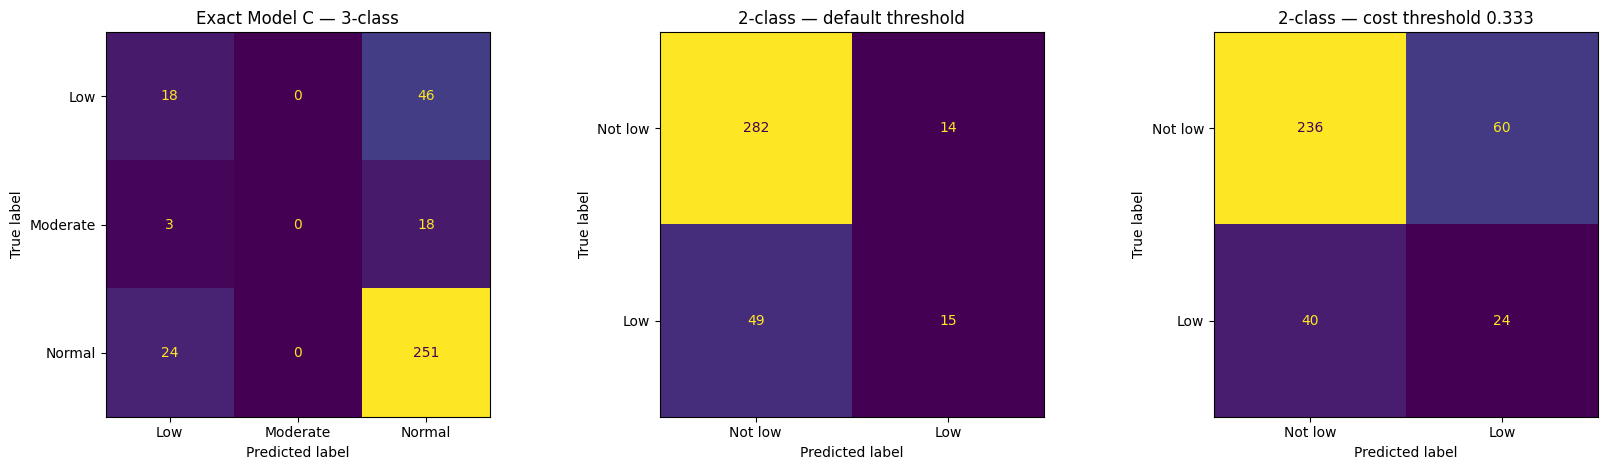

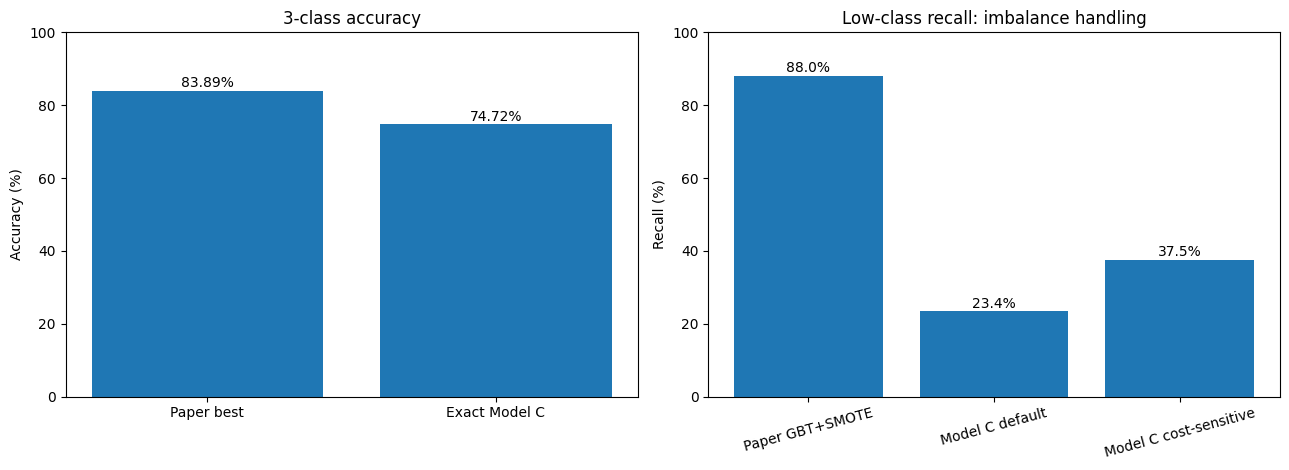

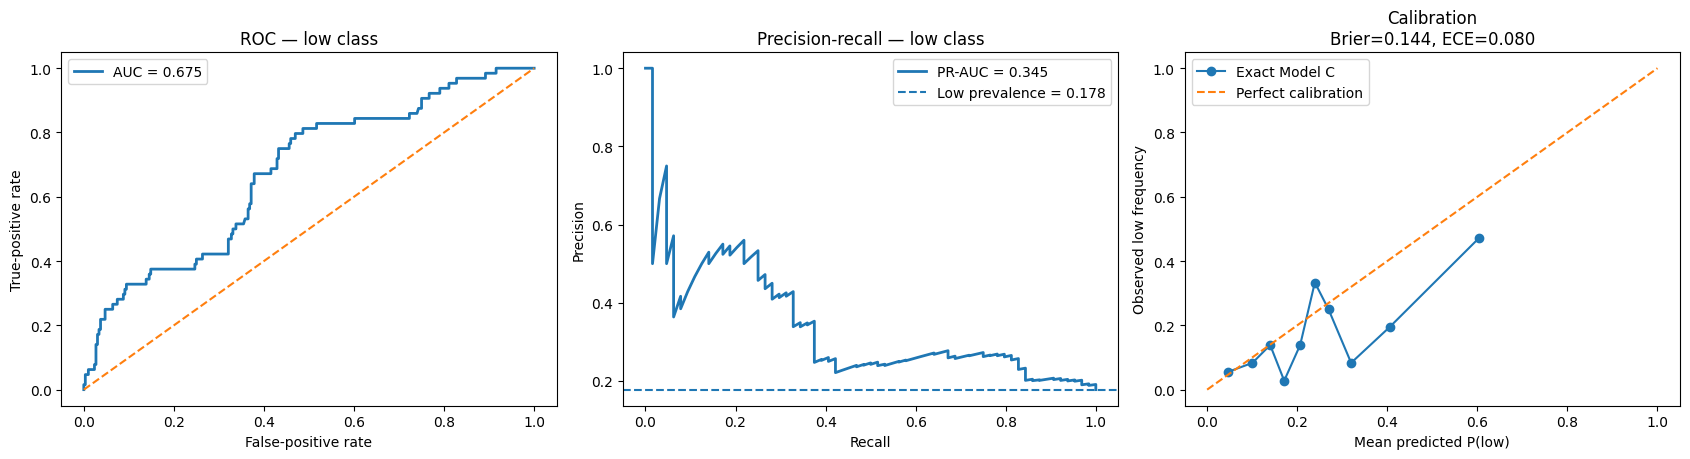

In [8]:
# ── Classification figures upgraded with Notebook 05 ideas ───────────────────

pred_default = (test_p_low >= 0.50).astype(int)
pred_cost = (test_p_low >= COST_THRESHOLD).astype(int)

# 1. Three confusion matrices: 3-class, default binary, cost-sensitive binary.
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

ConfusionMatrixDisplay(
    confusion_matrix(
        y3_test,
        test_pred_3,
        labels=[0, 1, 2],
    ),
    display_labels=["Low", "Moderate", "Normal"],
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Exact Model C — 3-class")

ConfusionMatrixDisplay(
    confusion_matrix(
        y2_test,
        pred_default,
        labels=[0, 1],
    ),
    display_labels=["Not low", "Low"],
).plot(ax=axes[1], colorbar=False)
axes[1].set_title("2-class — default threshold")

ConfusionMatrixDisplay(
    confusion_matrix(
        y2_test,
        pred_cost,
        labels=[0, 1],
    ),
    display_labels=["Not low", "Low"],
).plot(ax=axes[2], colorbar=False)
axes[2].set_title(
    f"2-class — cost threshold {COST_THRESHOLD:.3f}"
)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "validation_confusion_matrices.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

# 2. Direct paper benchmark comparison.
model_3_accuracy = float(model_3["accuracy"])
default_low_recall = float(model_2_default["low_recall"])
cost_low_recall = float(model_2_cost["low_recall"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

labels_3 = ["Paper best", "Exact Model C"]
values_3 = [
    100.0 * PAPER_3CLASS["accuracy"],
    100.0 * model_3_accuracy,
]

axes[0].bar(labels_3, values_3)
axes[0].set_title("3-class accuracy")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 100)

for position, value in enumerate(values_3):
    axes[0].text(
        position,
        value + 1,
        f"{value:.2f}%",
        ha="center",
    )

labels_2 = [
    "Paper GBT+SMOTE",
    "Model C default",
    "Model C cost-sensitive",
]
values_2 = [
    100.0 * PAPER_2CLASS["low_recall"],
    100.0 * default_low_recall,
    100.0 * cost_low_recall,
]

axes[1].bar(labels_2, values_2)
axes[1].set_title("Low-class recall: imbalance handling")
axes[1].set_ylabel("Recall (%)")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis="x", rotation=15)

for position, value in enumerate(values_2):
    axes[1].text(
        position,
        value + 1,
        f"{value:.1f}%",
        ha="center",
    )

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "validation_paper_benchmark_comparison.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

# 3. ROC, precision-recall, and calibration.
fpr, tpr, _ = roc_curve(y2_test, test_p_low)
precision_curve, recall_curve, _ = precision_recall_curve(
    y2_test,
    test_p_low,
)
fraction_positive, mean_probability = calibration_curve(
    y2_test,
    test_p_low,
    n_bins=10,
    strategy="quantile",
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.7))

axes[0].plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {model_2_default['auc']:.3f}",
)
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_xlabel("False-positive rate")
axes[0].set_ylabel("True-positive rate")
axes[0].set_title("ROC — low class")
axes[0].legend()

axes[1].plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=(
        "PR-AUC = "
        f"{model_2_default['average_precision']:.3f}"
    ),
)
axes[1].axhline(
    y2_test.mean(),
    linestyle="--",
    label=f"Low prevalence = {y2_test.mean():.3f}",
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall — low class")
axes[1].legend()

axes[2].plot(
    mean_probability,
    fraction_positive,
    marker="o",
    label="Exact Model C",
)
axes[2].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration",
)
axes[2].set_xlabel("Mean predicted P(low)")
axes[2].set_ylabel("Observed low frequency")
axes[2].set_title(
    "Calibration\n"
    f"Brier={model_2_default['brier']:.3f}, "
    f"ECE={model_2_default['ece_10bin']:.3f}"
)
axes[2].legend()

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "validation_roc_pr_calibration.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()


## 7. Regression accuracy and uncertainty coverage on the exact holdout

,model,split,n,mae,rmse,r2,coverage80,coverage95,mean_pi80_width,mean_pi95_width
0,Exact Bayesian Model C,paper-style random test,360,0.094972,0.130132,0.413458,0.844444,0.952778,0.391024,0.565803


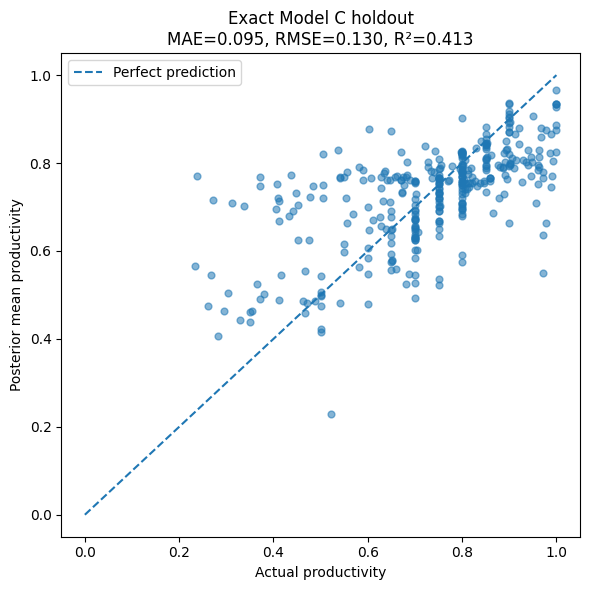

In [9]:
posterior_mean_test = mu_test_samples.mean(axis=0)
regression_summary = {
    "model": "Exact Bayesian Model C",
    "split": "paper-style random test",
    "n": len(y_test_saved),
    "mae": mean_absolute_error(y_test_saved, posterior_mean_test),
    "rmse": mean_squared_error(y_test_saved, posterior_mean_test) ** 0.5,
    "r2": r2_score(y_test_saved, posterior_mean_test),
}

if MODEL_C_TEST_TABLE_PATH.exists():
    interval_table = pd.read_csv(MODEL_C_TEST_TABLE_PATH)
    interval_table = interval_table.set_index("original_row_index").loc[test_indices].reset_index()
    regression_summary["coverage80"] = np.mean(
        (interval_table["actual_productivity"] >= interval_table["pi80_lower"])
        & (interval_table["actual_productivity"] <= interval_table["pi80_upper"])
    )
    regression_summary["coverage95"] = np.mean(
        (interval_table["actual_productivity"] >= interval_table["pi95_lower"])
        & (interval_table["actual_productivity"] <= interval_table["pi95_upper"])
    )
    regression_summary["mean_pi80_width"] = np.mean(interval_table["pi80_upper"] - interval_table["pi80_lower"])
    regression_summary["mean_pi95_width"] = np.mean(interval_table["pi95_upper"] - interval_table["pi95_lower"])
else:
    saved_metrics = metadata.get("test_metrics", {})
    regression_summary["coverage80"] = saved_metrics.get("coverage80", np.nan)
    regression_summary["coverage95"] = saved_metrics.get("coverage95", np.nan)
    regression_summary["mean_pi80_width"] = np.nan
    regression_summary["mean_pi95_width"] = np.nan

regression_metrics = pd.DataFrame([regression_summary])
regression_metrics.to_csv(OUTPUT_DIR / "validation_bayesian_regression_metrics.csv", index=False)
display(regression_metrics)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_saved, posterior_mean_test, alpha=0.55, s=24)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect prediction")
plt.xlabel("Actual productivity")
plt.ylabel("Posterior mean productivity")
plt.title(
    "Exact Model C holdout\n"
    f"MAE={regression_summary['mae']:.3f}, RMSE={regression_summary['rmse']:.3f}, "
    f"R²={regression_summary['r2']:.3f}"
)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "validation_bayesian_regression_scatter.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. PSIS-LOO and posterior driver validation against the garment paper

,Unnamed: 0,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
0,Model_C_final_monotone,0,562.184137,27.617370,0.000000,9.551571e-01,29.676019,0.000000,False,log
1,Model_B_hierarchical,1,468.186923,21.525167,93.997213,1.012652e-12,24.021913,14.575043,False,log
2,Model_A_baseline,2,441.976992,9.730148,120.207144,4.484290e-02,21.868118,16.984023,False,log


,variable,label,posterior_mean,hdi3,hdi97,prob_positive,prob_negative,direction,paper_comparison
0,b_inc_positive,Positive incentive vs zero,-0.570511,-0.866349,-0.286493,0.00025,0.99975,credibly negative,Paper: incentive is primary; expected alignmen...
1,b_wip,log WIP,0.408659,0.049043,0.761610,0.98175,0.01825,credibly positive,Paper: lower WIP is favorable; expected alignm...
2,b_ot,log overtime,-0.082871,-0.154156,-0.017421,0.01000,0.99000,credibly negative,Not a direct paper rule
3,b_smv,log SMV,0.020818,-0.212843,0.242442,0.57350,0.42650,uncertain / includes zero,Not a direct paper rule
4,b_nw,log workers,0.214928,-0.018045,0.457327,0.95900,0.04100,uncertain / includes zero,Paper: more workers can be favorable; expected...
5,b_tp,targeted productivity,0.175810,0.120833,0.232118,1.00000,0.00000,credibly positive,Not a direct paper rule
6,b_style,style changes,0.012998,-0.041024,0.068586,0.66525,0.33475,uncertain / includes zero,Not a direct paper rule
7,b_sin,weekday sine,0.003236,-0.048267,0.055537,0.54025,0.45975,uncertain / includes zero,Not a direct paper rule
8,b_cos,weekday cosine,0.000710,-0.048951,0.050659,0.52100,0.47900,uncertain / includes zero,Not a direct paper rule
9,b_dept,sewing department,-0.502103,-1.563577,0.546817,0.17875,0.82125,uncertain / includes zero,Not a direct paper rule


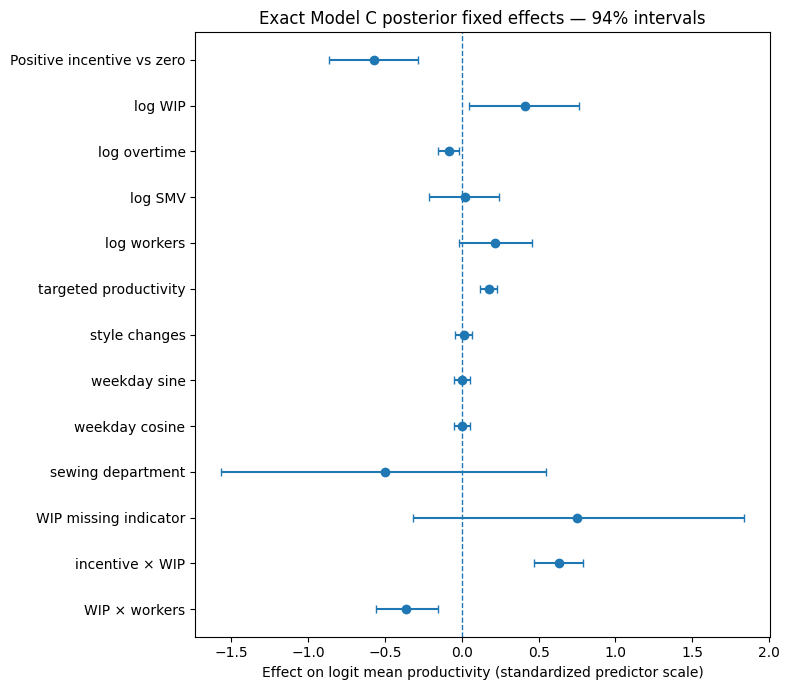

In [10]:
if LOO_PATH.exists():
    loo_table = pd.read_csv(LOO_PATH)
    loo_table.to_csv(OUTPUT_DIR / "validation_loo_comparison_copy.csv", index=False)
    display(loo_table)
else:
    loo_table = pd.DataFrame()
    print("LOO table not found; posterior driver validation will continue.")

fixed_effects = {
    "b_inc_positive": "Positive incentive vs zero",
    "b_wip": "log WIP",
    "b_ot": "log overtime",
    "b_smv": "log SMV",
    "b_nw": "log workers",
    "b_tp": "targeted productivity",
    "b_style": "style changes",
    "b_sin": "weekday sine",
    "b_cos": "weekday cosine",
    "b_dept": "sewing department",
    "b_wip_miss": "WIP missing indicator",
    "b_inc_wip": "incentive × WIP",
    "b_wip_nw": "WIP × workers",
}

driver_rows = []
for variable, label in fixed_effects.items():
    draws = posterior_samples(variable).reshape(-1)
    driver_rows.append({
        "variable": variable,
        "label": label,
        "posterior_mean": np.mean(draws),
        "hdi3": np.quantile(draws, 0.03),
        "hdi97": np.quantile(draws, 0.97),
        "prob_positive": np.mean(draws > 0),
        "prob_negative": np.mean(draws < 0),
    })

driver_table = pd.DataFrame(driver_rows)

def evidence_direction(row):
    if row["hdi3"] > 0:
        return "credibly positive"
    if row["hdi97"] < 0:
        return "credibly negative"
    return "uncertain / includes zero"

driver_table["direction"] = driver_table.apply(evidence_direction, axis=1)

paper_links = {
    "b_inc_positive": "Paper: incentive is primary; expected alignment is positive",
    "b_wip": "Paper: lower WIP is favorable; expected alignment is negative",
    "b_nw": "Paper: more workers can be favorable; expected alignment is positive",
    "b_inc_wip": "Paper rule combines incentive and WIP",
    "b_wip_nw": "Paper rule combines WIP and workers",
}
driver_table["paper_comparison"] = driver_table["variable"].map(paper_links).fillna("Not a direct paper rule")
driver_table.to_csv(OUTPUT_DIR / "validation_posterior_driver_table.csv", index=False)
display(driver_table)

plot_table = driver_table.iloc[::-1]
plt.figure(figsize=(8, 7))
plt.errorbar(
    plot_table["posterior_mean"],
    np.arange(len(plot_table)),
    xerr=[
        plot_table["posterior_mean"] - plot_table["hdi3"],
        plot_table["hdi97"] - plot_table["posterior_mean"],
    ],
    fmt="o",
    capsize=3,
)
plt.axvline(0, linestyle="--", linewidth=1)
plt.yticks(np.arange(len(plot_table)), plot_table["label"])
plt.xlabel("Effect on logit mean productivity (standardized predictor scale)")
plt.title("Exact Model C posterior fixed effects — 94% intervals")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "validation_posterior_drivers.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. Reconstruct the exact Model C prediction function for what-if validation

In [11]:
def b_spline_basis(x, knots, degree=3):
    x = np.asarray(x, dtype=float)
    knots = np.asarray(knots, dtype=float)
    knot_vector = np.concatenate([
        np.repeat(knots[0], degree),
        knots,
        np.repeat(knots[-1], degree),
    ])
    n_basis = len(knot_vector) - degree - 1
    basis = np.zeros((len(x), n_basis), dtype=float)
    for i in range(n_basis):
        coefficient = np.zeros(n_basis, dtype=float)
        coefficient[i] = 1.0
        spline = BSpline(knot_vector, coefficient, degree, extrapolate=False)
        basis[:, i] = spline(x)
    return np.nan_to_num(basis, nan=0.0, posinf=0.0, neginf=0.0)


def i_spline_basis(x, knots, degree=3):
    basis = b_spline_basis(x, knots, degree)
    cumulative = np.cumsum(basis[:, ::-1], axis=1)[:, ::-1]
    return cumulative[:, 1:]


FEATURES = list(metadata["feature_columns"])
SCALER_MEAN = np.asarray(metadata["scaler_mean"], float)
SCALER_SCALE = np.asarray(metadata["scaler_scale"], float)
COL = {name: i for i, name in enumerate(FEATURES)}
KNOTS = np.asarray(metadata["spline_knots_standardized_log_incentive"], float)
SPLINE_DEGREE = int(metadata["spline_degree"])
SPLINE_LOWER = float(metadata["spline_lower"])
SPLINE_UPPER = float(metadata["spline_upper"])
TEAM_LABELS = list(metadata["team_labels"])


def normalized_key(value):
    try:
        f = float(value)
        if f.is_integer():
            return str(int(f))
    except Exception:
        pass
    return str(value).strip()

TEAM_MAP = {normalized_key(value): idx for idx, value in enumerate(TEAM_LABELS)}

all_draws = posterior_samples("nu").shape[0]
if all_draws > MAX_POSTERIOR_DRAWS:
    MODEL_DRAW_IDX = np.sort(rng.choice(all_draws, MAX_POSTERIOR_DRAWS, replace=False))
else:
    MODEL_DRAW_IDX = np.arange(all_draws)


def pdraw(name):
    return posterior_samples(name)[MODEL_DRAW_IDX]

POST = {name: pdraw(name) for name in [
    "alpha_team", "mu_team", "w_spline", "b_inc_positive", "b_wip",
    "b_ot", "b_smv", "b_nw", "b_tp", "b_style", "b_sin", "b_cos",
    "b_dept", "b_wip_miss", "b_inc_wip", "b_wip_nw", "nu",
]}


def prepare_model_frame(frame):
    out = frame.copy()
    out["incentive"] = raw_from_columns(out, ["incentive"], ["log_incentive"]).fillna(0).clip(lower=0)
    out["wip_imputed"] = raw_from_columns(out, ["wip_imputed", "wip"], ["log_wip_imputed"]).fillna(0).clip(lower=0)
    out["over_time"] = raw_from_columns(out, ["over_time"], ["log_over_time"]).fillna(0).clip(lower=0)
    out["smv"] = raw_from_columns(out, ["smv"], ["log_smv"]).fillna(0).clip(lower=0)
    out["no_of_workers"] = raw_from_columns(out, ["no_of_workers"], ["log_workers"]).fillna(0).clip(lower=0)

    out["log_incentive"] = np.log1p(out["incentive"])
    out["log_wip_imputed"] = np.log1p(out["wip_imputed"])
    out["log_over_time"] = np.log1p(out["over_time"])
    out["log_smv"] = np.log1p(out["smv"])
    out["log_workers"] = np.log1p(out["no_of_workers"])

    if "sin_dow" not in out or "cos_dow" not in out:
        if "day_num" in out:
            day_num = pd.to_numeric(out["day_num"], errors="coerce").fillna(0)
        elif "date" in out:
            day_num = pd.to_datetime(out["date"], errors="coerce").dt.dayofweek.fillna(0)
        else:
            day_num = pd.Series(0, index=out.index)
        out["sin_dow"] = np.sin(2 * np.pi * day_num / 7)
        out["cos_dow"] = np.cos(2 * np.pi * day_num / 7)

    if "dept_bin" not in out:
        department = out.get("department", pd.Series("finishing", index=out.index)).astype(str).str.lower()
        out["dept_bin"] = department.str.contains("sew").astype(int)
    if "wip_missing_flag" not in out:
        out["wip_missing_flag"] = 0

    for col in FEATURES:
        if col not in out:
            raise KeyError(f"Model C feature missing from intervention frame: {col}")
        out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0.0)
    return out


def model_c_mu_draws(frame, population_average_team=False):
    frame = prepare_model_frame(frame)
    X_raw = frame[FEATURES].to_numpy(float)
    X = (X_raw - SCALER_MEAN) / SCALER_SCALE

    incentive_std = X[:, COL["log_incentive"]]
    spline_x = np.clip(incentive_std, SPLINE_LOWER, SPLINE_UPPER)
    I = i_spline_basis(spline_x, KNOTS, degree=SPLINE_DEGREE)

    if population_average_team:
        intercept = POST["mu_team"][:, None]
    else:
        team_idx = np.array([
            TEAM_MAP.get(normalized_key(value), -1) for value in frame["team"]
        ])
        known = team_idx >= 0
        intercept = np.repeat(POST["mu_team"][:, None], len(frame), axis=1)
        if known.any():
            intercept[:, known] = POST["alpha_team"][:, team_idx[known]]

    inc_positive = (frame["incentive"].to_numpy(float) > 0).astype(float)
    wip = X[:, COL["log_wip_imputed"]]
    inc = X[:, COL["log_incentive"]]
    workers = X[:, COL["log_workers"]]

    eta = (
        intercept
        + POST["b_inc_positive"][:, None] * inc_positive[None, :]
        + POST["w_spline"] @ I.T
        + POST["b_wip"][:, None] * wip[None, :]
        + POST["b_ot"][:, None] * X[:, COL["log_over_time"]][None, :]
        + POST["b_smv"][:, None] * X[:, COL["log_smv"]][None, :]
        + POST["b_nw"][:, None] * workers[None, :]
        + POST["b_tp"][:, None] * X[:, COL["targeted_productivity"]][None, :]
        + POST["b_style"][:, None] * X[:, COL["no_of_style_change"]][None, :]
        + POST["b_sin"][:, None] * X[:, COL["sin_dow"]][None, :]
        + POST["b_cos"][:, None] * X[:, COL["cos_dow"]][None, :]
        + POST["b_dept"][:, None] * frame["dept_bin"].to_numpy(float)[None, :]
        + POST["b_wip_miss"][:, None] * frame["wip_missing_flag"].to_numpy(float)[None, :]
        + POST["b_inc_wip"][:, None] * (inc * wip)[None, :]
        + POST["b_wip_nw"][:, None] * (wip * workers)[None, :]
    )
    mu_beta = expit(np.clip(eta, -30, 30))
    if USES_SV:
        mu_original = (mu_beta * N_BETA - 0.5) / (N_BETA - 1)
    else:
        mu_original = mu_beta
    return np.clip(mu_original, 0.0, 1.0), POST["nu"].reshape(-1)


def low_risk_draws(mu_original, target_productivity, nu_draws):
    mu_beta = original_to_beta(mu_original)
    threshold_beta = original_to_beta(LOW_ACHIEVEMENT * np.asarray(target_productivity, float))
    alpha = np.clip(mu_beta * nu_draws[:, None], 1e-8, None)
    beta = np.clip((1 - mu_beta) * nu_draws[:, None], 1e-8, None)
    return betainc(alpha, beta, threshold_beta[None, :])

# Numerical identity check against the saved test predictions.
reconstructed_mu, reconstructed_nu = model_c_mu_draws(test_frame)
identity_check = pd.DataFrame([{
    "saved_mean_mae_vs_reconstructed": mean_absolute_error(
        mu_test_samples.mean(axis=0), reconstructed_mu.mean(axis=0)
    ),
    "saved_mean_max_abs_difference": np.max(np.abs(
        mu_test_samples.mean(axis=0) - reconstructed_mu.mean(axis=0)
    )),
    "posterior_draws_used_for_whatif": len(MODEL_DRAW_IDX),
}])
identity_check.to_csv(OUTPUT_DIR / "validation_model_c_reconstruction_check.csv", index=False)
display(identity_check)

,saved_mean_mae_vs_reconstructed,saved_mean_max_abs_difference,posterior_draws_used_for_whatif
0,0.000366,0.003452,1000


## 9A. Paper-specific driver validation using the exact Model C

Notebook 05 correctly emphasized a direct comparison with the paper's incentive, WIP, and worker rules. This upgraded section keeps that idea but computes every quantity from the already-loaded authoritative Model C posterior.

The incentive contrast is conditional on median fitted WIP and includes:

- the positive-incentive indicator;
- the monotone incentive spline;
- the incentive × WIP interaction.

It is therefore more faithful to Model C than reading a single linear incentive coefficient.


,factor,posterior_mean,hdi_3%,hdi_97%,P(effect > 0),P(effect < 0),bayesian_conclusion,paper_direction_or_rule,alignment_with_paper
0,Incentive: 0 → 69.5 BDT (conditional at median...,1.094397,0.892954,1.304843,1.000,0.000,Credibly positive,Paper identifies incentive as primary and uses...,Aligned
1,WIP coefficient,0.402928,0.047051,0.761647,0.979,0.021,Credibly positive,Paper associates lower WIP with better product...,Not clearly aligned
2,Number of workers coefficient,0.212962,-0.019934,0.455291,0.955,0.045,Uncertain / overlaps zero,Paper rules indicate more workers can shift ca...,Not clearly aligned
3,Incentive × WIP interaction,0.635030,0.480001,0.797763,1.000,0.000,Credibly positive,Paper combines incentive and WIP in its decisi...,Interaction assessed; the paper gives a rule r...
4,WIP × workers interaction,-0.365848,-0.555168,-0.154577,0.000,1.000,Credibly negative,Paper combines WIP and workers in its decision...,Interaction assessed; the paper gives a rule r...


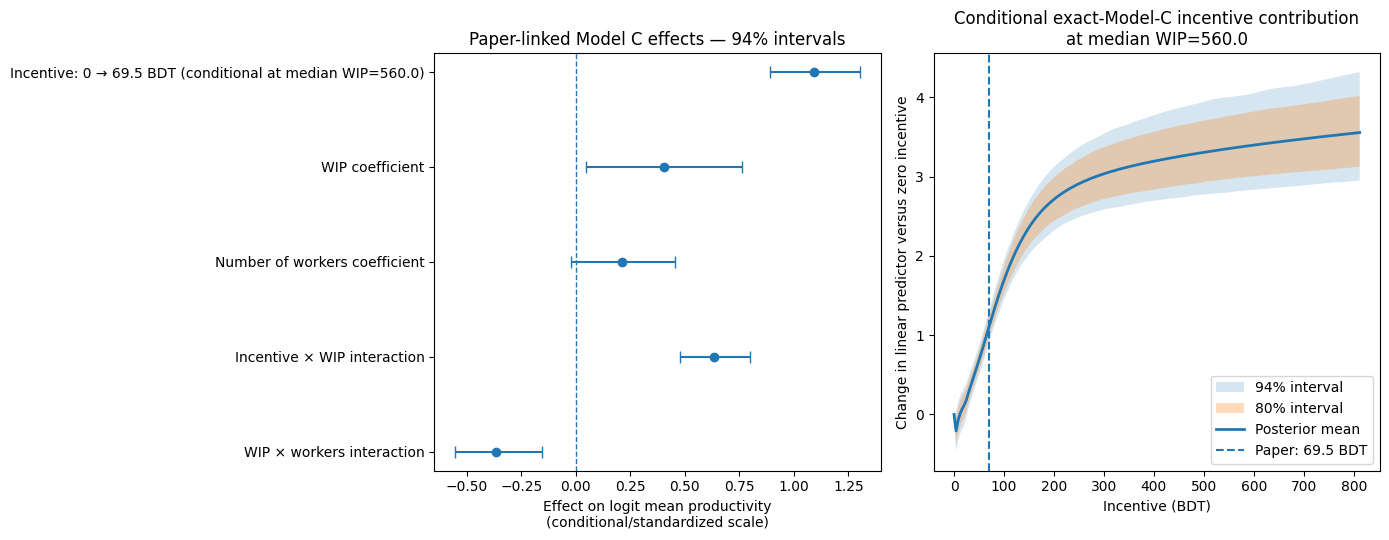

In [12]:
# ── Exact-Model-C driver contrasts aligned with the garment paper ─────────────

def posterior_interval(values, probability=0.94):
    values = np.asarray(values, dtype=float)
    tail = (1.0 - probability) / 2.0
    return np.quantile(values, [tail, 1.0 - tail])


def summarize_effect(
    factor,
    samples,
    paper_direction_or_rule,
):
    samples = np.asarray(samples, dtype=float).reshape(-1)
    low, high = posterior_interval(samples, probability=0.94)

    if low > 0:
        conclusion = "Credibly positive"
    elif high < 0:
        conclusion = "Credibly negative"
    else:
        conclusion = "Uncertain / overlaps zero"

    return {
        "factor": factor,
        "posterior_mean": float(np.mean(samples)),
        "hdi_3%": float(low),
        "hdi_97%": float(high),
        "P(effect > 0)": float(np.mean(samples > 0)),
        "P(effect < 0)": float(np.mean(samples < 0)),
        "bayesian_conclusion": conclusion,
        "paper_direction_or_rule": paper_direction_or_rule,
    }


def standardized_log_feature(raw_values, feature_name):
    raw_values = np.asarray(raw_values, dtype=float)
    log_values = np.log1p(np.clip(raw_values, 0.0, None))
    index = COL[feature_name]
    return (
        log_values - SCALER_MEAN[index]
    ) / SCALER_SCALE[index]


fit_frame_for_drivers = df.iloc[fit_indices].copy()
median_wip_raw = float(
    pd.to_numeric(
        fit_frame_for_drivers["wip_imputed"],
        errors="coerce",
    ).median()
)
median_wip_std = float(
    standardized_log_feature(
        [median_wip_raw],
        "log_wip_imputed",
    )[0]
)

inc_0_std = standardized_log_feature(
    [0.0],
    "log_incentive",
)
inc_69_5_std = standardized_log_feature(
    [PAPER_INCENTIVE_THRESHOLD],
    "log_incentive",
)

I_0 = i_spline_basis(
    np.clip(inc_0_std, SPLINE_LOWER, SPLINE_UPPER),
    KNOTS,
    degree=SPLINE_DEGREE,
)
I_69_5 = i_spline_basis(
    np.clip(inc_69_5_std, SPLINE_LOWER, SPLINE_UPPER),
    KNOTS,
    degree=SPLINE_DEGREE,
)

spline_change_0_to_69_5 = (
    POST["w_spline"] @ I_69_5.T
    - POST["w_spline"] @ I_0.T
).reshape(-1)

positive_indicator_change = POST[
    "b_inc_positive"
].reshape(-1)

interaction_change_0_to_69_5 = (
    POST["b_inc_wip"].reshape(-1)
    * (
        float(inc_69_5_std[0])
        - float(inc_0_std[0])
    )
    * median_wip_std
)

conditional_incentive_change = (
    positive_indicator_change
    + spline_change_0_to_69_5
    + interaction_change_0_to_69_5
)

paper_driver_rows = [
    summarize_effect(
        "Incentive: 0 → 69.5 BDT "
        f"(conditional at median WIP={median_wip_raw:.1f})",
        conditional_incentive_change,
        "Paper identifies incentive as primary and uses a 69.5 BDT split",
    ),
    summarize_effect(
        "WIP coefficient",
        POST["b_wip"],
        "Paper associates lower WIP with better productivity class",
    ),
    summarize_effect(
        "Number of workers coefficient",
        POST["b_nw"],
        "Paper rules indicate more workers can shift cases away from low",
    ),
    summarize_effect(
        "Incentive × WIP interaction",
        POST["b_inc_wip"],
        "Paper combines incentive and WIP in its decision rules",
    ),
    summarize_effect(
        "WIP × workers interaction",
        POST["b_wip_nw"],
        "Paper combines WIP and workers in its decision rules",
    ),
]

paper_driver_validation = pd.DataFrame(
    paper_driver_rows
)


def alignment_with_paper(row):
    factor = row["factor"].lower()
    conclusion = row["bayesian_conclusion"].lower()

    if factor.startswith("incentive:"):
        return (
            "Aligned"
            if "positive" in conclusion
            else "Not clearly aligned"
        )

    if factor.startswith("wip coefficient"):
        return (
            "Aligned"
            if "negative" in conclusion
            else "Not clearly aligned"
        )

    if factor.startswith("number of workers"):
        return (
            "Aligned"
            if "positive" in conclusion
            else "Not clearly aligned"
        )

    return (
        "Interaction assessed; the paper gives a rule "
        "rather than a signed coefficient"
    )


paper_driver_validation["alignment_with_paper"] = (
    paper_driver_validation.apply(
        alignment_with_paper,
        axis=1,
    )
)

paper_driver_validation.to_csv(
    OUTPUT_DIR / "validation_paper_driver_alignment.csv",
    index=False,
)
display(paper_driver_validation)

# Conditional incentive contribution curve from the exact Model C.
incentive_effect_grid = np.linspace(
    0.0,
    max(
        160.0,
        float(
            pd.to_numeric(
                fit_frame_for_drivers["incentive"],
                errors="coerce",
            ).quantile(0.995)
        ),
    ),
    201,
)

incentive_effect_std = standardized_log_feature(
    incentive_effect_grid,
    "log_incentive",
)

I_effect_grid = i_spline_basis(
    np.clip(
        incentive_effect_std,
        SPLINE_LOWER,
        SPLINE_UPPER,
    ),
    KNOTS,
    degree=SPLINE_DEGREE,
)

conditional_incentive_contribution = (
    POST["w_spline"] @ I_effect_grid.T
    + POST["b_inc_positive"][:, None]
    * (incentive_effect_grid > 0).astype(float)[None, :]
    + POST["b_inc_wip"][:, None]
    * (
        incentive_effect_std
        * median_wip_std
    )[None, :]
)

# Express the curve relative to zero incentive for interpretation.
conditional_incentive_contribution = (
    conditional_incentive_contribution
    - conditional_incentive_contribution[:, [0]]
)

effect_mean = conditional_incentive_contribution.mean(axis=0)
effect_lo94, effect_hi94 = np.quantile(
    conditional_incentive_contribution,
    [0.03, 0.97],
    axis=0,
)
effect_lo80, effect_hi80 = np.quantile(
    conditional_incentive_contribution,
    [0.10, 0.90],
    axis=0,
)

incentive_effect_table = pd.DataFrame({
    "incentive_bdt": incentive_effect_grid,
    "conditional_effect_mean": effect_mean,
    "conditional_effect_p03": effect_lo94,
    "conditional_effect_p10": effect_lo80,
    "conditional_effect_p90": effect_hi80,
    "conditional_effect_p97": effect_hi94,
    "reference_wip_pieces": median_wip_raw,
})

incentive_effect_table.to_csv(
    OUTPUT_DIR / "validation_exact_model_c_incentive_effect.csv",
    index=False,
)

plot_driver = paper_driver_validation.iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

driver_error = np.vstack([
    plot_driver["posterior_mean"]
    - plot_driver["hdi_3%"],
    plot_driver["hdi_97%"]
    - plot_driver["posterior_mean"],
])

axes[0].errorbar(
    plot_driver["posterior_mean"],
    plot_driver["factor"],
    xerr=driver_error,
    fmt="o",
    capsize=4,
)
axes[0].axvline(0.0, linestyle="--", linewidth=1)
axes[0].set_title("Paper-linked Model C effects — 94% intervals")
axes[0].set_xlabel(
    "Effect on logit mean productivity\n"
    "(conditional/standardized scale)"
)

axes[1].fill_between(
    incentive_effect_grid,
    effect_lo94,
    effect_hi94,
    alpha=0.18,
    label="94% interval",
)
axes[1].fill_between(
    incentive_effect_grid,
    effect_lo80,
    effect_hi80,
    alpha=0.28,
    label="80% interval",
)
axes[1].plot(
    incentive_effect_grid,
    effect_mean,
    linewidth=2,
    label="Posterior mean",
)
axes[1].axvline(
    PAPER_INCENTIVE_THRESHOLD,
    linestyle="--",
    linewidth=1.5,
    label="Paper: 69.5 BDT",
)
axes[1].set_title(
    "Conditional exact-Model-C incentive contribution\n"
    f"at median WIP={median_wip_raw:.1f}"
)
axes[1].set_xlabel("Incentive (BDT)")
axes[1].set_ylabel(
    "Change in linear predictor versus zero incentive"
)
axes[1].legend()

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "validation_paper_driver_and_incentive_effect.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()


## 10. What-if uplift, risk reduction, and team heterogeneity

,intervention,mean_productivity_uplift,median_productivity_uplift,mean_low_risk_change,median_probability_positive,median_probability_risk_decreases,n
0,incentive_plus_20_BDT,-0.106208,0.042223,0.197612,0.9995,0.9995,360
1,wip_minus_20_percent,-0.003258,0.000000,0.006103,0.0000,0.0000,360
2,workers_plus_5,0.018815,-0.001080,-0.028003,0.3605,0.3605,360


,scenario,scenario_label,expected_productivity,expected_productivity_p10,expected_productivity_p90,expected_productivity_p03,expected_productivity_p97,productivity_change_vs_baseline,probability_productivity_improves,probability_low_productivity,probability_low_p10,probability_low_p90,probability_low_p03,probability_low_p97,low_risk_change_vs_baseline,probability_low_risk_decreases
0,baseline,Baseline,0.727580,0.720503,0.735081,0.716561,0.737868,0.000000,0.000,0.250523,0.234972,0.264824,0.229732,0.272548,0.000000,0.000
1,incentive_plus_20_BDT,+20 BDT incentive,0.621372,0.587888,0.655174,0.574595,0.675512,-0.106208,0.000,0.448134,0.405335,0.484778,0.369604,0.494373,0.197612,0.000
2,wip_minus_20_percent,Reduce WIP by 20%,0.724323,0.717027,0.732104,0.713414,0.735261,-0.003258,0.008,0.256625,0.240996,0.271510,0.234736,0.279132,0.006103,0.009
3,workers_plus_5,+5 workers,0.746395,0.737786,0.754523,0.734771,0.758316,0.018815,1.000,0.222520,0.207173,0.238210,0.200646,0.245283,-0.028003,1.000


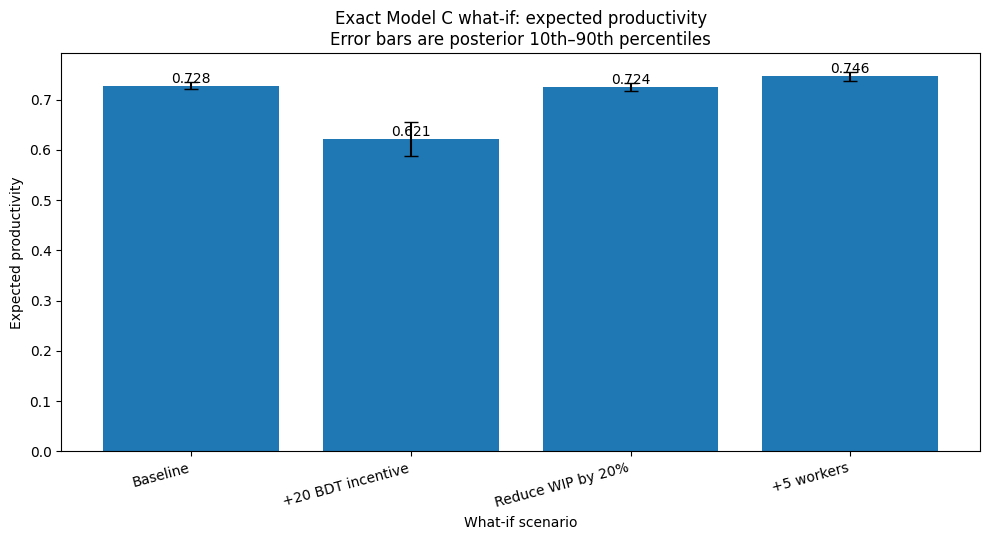

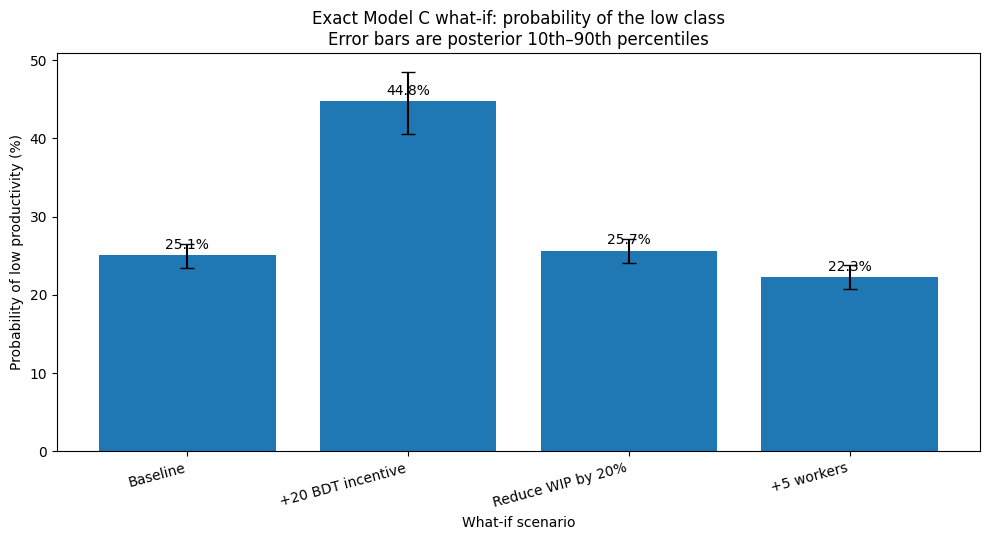

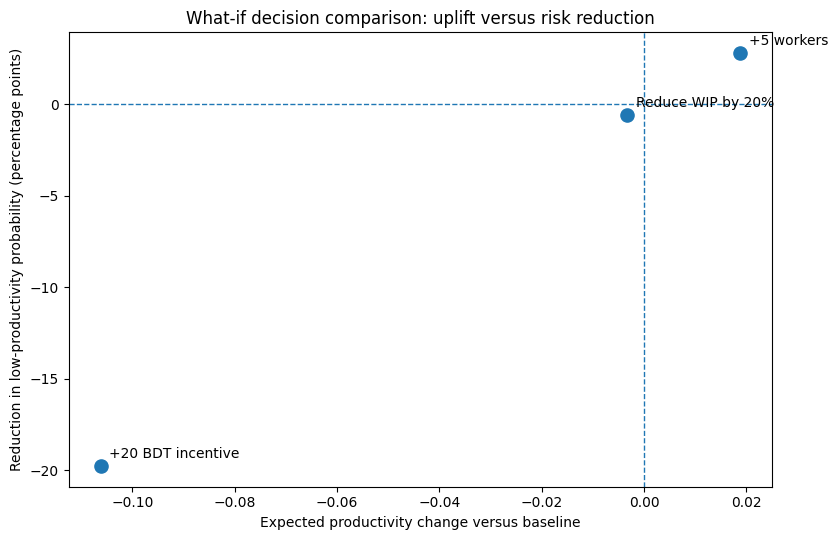

,team,n_test_rows,mean_uplift_plus20,p10,p90,prob_positive
4,5,24,-0.041474,-0.062855,-0.019559,0.014
10,11,27,-0.074354,-0.099199,-0.050125,0.000
1,2,24,-0.085851,-0.117210,-0.055017,0.000
7,8,35,-0.090416,-0.121211,-0.058475,0.000
2,3,30,-0.094697,-0.125331,-0.065429,0.000
5,6,22,-0.096097,-0.126775,-0.064348,0.000
8,9,44,-0.100672,-0.131123,-0.070562,0.000
6,7,32,-0.107753,-0.141823,-0.071922,0.000
11,12,29,-0.115192,-0.148261,-0.082058,0.000
9,10,31,-0.146166,-0.184478,-0.107256,0.000


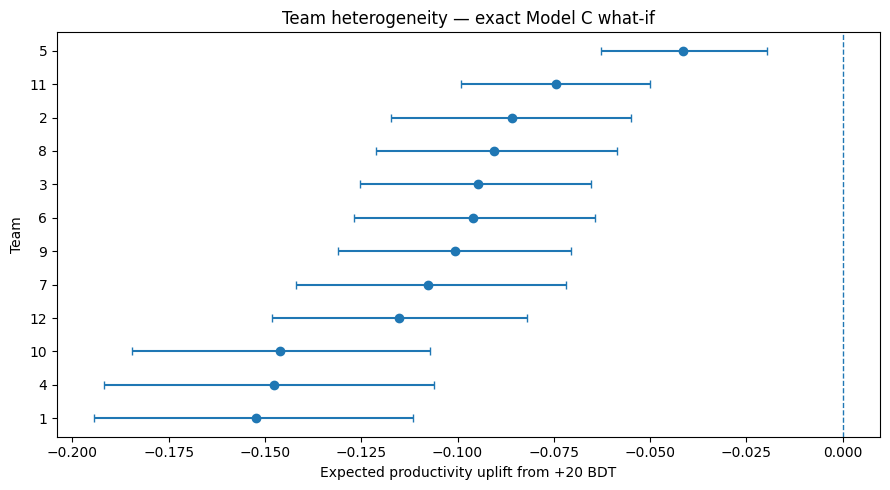

In [13]:
# ── Exact Model C what-if analysis ────────────────────────────────────────────

base = test_frame.copy()

inc_plus_20 = base.copy()
inc_plus_20["incentive"] = (
    inc_plus_20["incentive"] + 20.0
)

wip_minus_20pct = base.copy()
wip_minus_20pct["wip_imputed"] = (
    0.8 * wip_minus_20pct["wip_imputed"]
)

workers_plus_5 = base.copy()
workers_plus_5["no_of_workers"] = (
    workers_plus_5["no_of_workers"] + 5.0
)

mu_base, nu_sub = model_c_mu_draws(base)
risk_base = low_risk_draws(
    mu_base,
    base["targeted_productivity"].to_numpy(float),
    nu_sub,
)

interventions = {
    "incentive_plus_20_BDT": inc_plus_20,
    "wip_minus_20_percent": wip_minus_20pct,
    "workers_plus_5": workers_plus_5,
}

display_names = {
    "baseline": "Baseline",
    "incentive_plus_20_BDT": "+20 BDT incentive",
    "wip_minus_20_percent": "Reduce WIP by 20%",
    "workers_plus_5": "+5 workers",
}

whatif_rows = []
intervention_draws = {}

for name, scenario in interventions.items():
    mu_s, _ = model_c_mu_draws(scenario)
    risk_s = low_risk_draws(
        mu_s,
        scenario["targeted_productivity"].to_numpy(float),
        nu_sub,
    )

    uplift = mu_s - mu_base
    risk_change = risk_s - risk_base

    intervention_draws[name] = {
        "mu": mu_s,
        "risk": risk_s,
        "uplift": uplift,
        "risk_change": risk_change,
    }

    for j, original_idx in enumerate(
        base["original_row_index"].to_numpy(int)
    ):
        whatif_rows.append({
            "original_row_index": original_idx,
            "team": base.iloc[j]["team"],
            "intervention": name,
            "mean_productivity_uplift": uplift[:, j].mean(),
            "uplift_p10": np.quantile(
                uplift[:, j],
                0.10,
            ),
            "uplift_p90": np.quantile(
                uplift[:, j],
                0.90,
            ),
            "mean_low_risk_change": (
                risk_change[:, j].mean()
            ),
            "probability_positive_uplift": np.mean(
                uplift[:, j] > 0
            ),
            "probability_low_risk_decreases": np.mean(
                risk_change[:, j] < 0
            ),
        })

whatif_table = pd.DataFrame(whatif_rows)
whatif_table.to_csv(
    OUTPUT_DIR / "validation_whatif_row_level.csv",
    index=False,
)

whatif_summary = (
    whatif_table
    .groupby("intervention")
    .agg(
        mean_productivity_uplift=(
            "mean_productivity_uplift",
            "mean",
        ),
        median_productivity_uplift=(
            "mean_productivity_uplift",
            "median",
        ),
        mean_low_risk_change=(
            "mean_low_risk_change",
            "mean",
        ),
        median_probability_positive=(
            "probability_positive_uplift",
            "median",
        ),
        median_probability_risk_decreases=(
            "probability_low_risk_decreases",
            "median",
        ),
        n=("original_row_index", "size"),
    )
    .reset_index()
)

whatif_summary.to_csv(
    OUTPUT_DIR / "validation_whatif_summary.csv",
    index=False,
)
display(whatif_summary)

# ── Scenario-level expected productivity and low-class probability ────────────

scenario_draws = {
    "baseline": {
        "mu": mu_base,
        "risk": risk_base,
    },
    **{
        name: {
            "mu": values["mu"],
            "risk": values["risk"],
        }
        for name, values in intervention_draws.items()
    },
}

baseline_mean_productivity_draw = mu_base.mean(axis=1)
baseline_mean_risk_draw = risk_base.mean(axis=1)

scenario_rows = []
scenario_row_level = []

for scenario_name, values in scenario_draws.items():
    mu_s = np.asarray(values["mu"], float)
    risk_s = np.asarray(values["risk"], float)

    mean_productivity_draw = mu_s.mean(axis=1)
    mean_risk_draw = risk_s.mean(axis=1)

    productivity_change_draw = (
        mean_productivity_draw
        - baseline_mean_productivity_draw
    )
    risk_change_draw = (
        mean_risk_draw
        - baseline_mean_risk_draw
    )

    scenario_rows.append({
        "scenario": scenario_name,
        "scenario_label": display_names[scenario_name],
        "expected_productivity": (
            mean_productivity_draw.mean()
        ),
        "expected_productivity_p10": np.quantile(
            mean_productivity_draw,
            0.10,
        ),
        "expected_productivity_p90": np.quantile(
            mean_productivity_draw,
            0.90,
        ),
        "expected_productivity_p03": np.quantile(
            mean_productivity_draw,
            0.03,
        ),
        "expected_productivity_p97": np.quantile(
            mean_productivity_draw,
            0.97,
        ),
        "productivity_change_vs_baseline": (
            productivity_change_draw.mean()
        ),
        "probability_productivity_improves": np.mean(
            productivity_change_draw > 0
        ),
        "probability_low_productivity": (
            mean_risk_draw.mean()
        ),
        "probability_low_p10": np.quantile(
            mean_risk_draw,
            0.10,
        ),
        "probability_low_p90": np.quantile(
            mean_risk_draw,
            0.90,
        ),
        "probability_low_p03": np.quantile(
            mean_risk_draw,
            0.03,
        ),
        "probability_low_p97": np.quantile(
            mean_risk_draw,
            0.97,
        ),
        "low_risk_change_vs_baseline": (
            risk_change_draw.mean()
        ),
        "probability_low_risk_decreases": np.mean(
            risk_change_draw < 0
        ),
    })

    row_expected_productivity = mu_s.mean(axis=0)
    row_probability_low = risk_s.mean(axis=0)

    for row_position in range(len(base)):
        scenario_row_level.append({
            "original_row_index": int(
                base.iloc[row_position][
                    "original_row_index"
                ]
            ),
            "team": base.iloc[row_position]["team"],
            "scenario": scenario_name,
            "scenario_label": display_names[
                scenario_name
            ],
            "expected_productivity": (
                row_expected_productivity[
                    row_position
                ]
            ),
            "probability_low_productivity": (
                row_probability_low[
                    row_position
                ]
            ),
        })

whatif_probability_summary = pd.DataFrame(
    scenario_rows
)

whatif_probability_row_level = pd.DataFrame(
    scenario_row_level
)

whatif_probability_summary.to_csv(
    OUTPUT_DIR
    / "validation_whatif_productivity_low_risk_summary.csv",
    index=False,
)

whatif_probability_row_level.to_csv(
    OUTPUT_DIR
    / "validation_whatif_productivity_low_risk_rows.csv",
    index=False,
)

display(whatif_probability_summary)

# Expected productivity plot.
plot_scenarios = whatif_probability_summary.copy()
x_positions = np.arange(len(plot_scenarios))
productivity_mean = plot_scenarios[
    "expected_productivity"
].to_numpy(float)

productivity_error = np.vstack([
    productivity_mean
    - plot_scenarios[
        "expected_productivity_p10"
    ].to_numpy(float),
    plot_scenarios[
        "expected_productivity_p90"
    ].to_numpy(float)
    - productivity_mean,
])

plt.figure(figsize=(10, 5.5))
plt.bar(
    x_positions,
    productivity_mean,
    yerr=productivity_error,
    capsize=5,
)
plt.xticks(
    x_positions,
    plot_scenarios["scenario_label"],
    rotation=15,
    ha="right",
)
plt.ylabel("Expected productivity")
plt.xlabel("What-if scenario")
plt.title(
    "Exact Model C what-if: expected productivity\n"
    "Error bars are posterior 10th–90th percentiles"
)

for x_position, value in zip(
    x_positions,
    productivity_mean,
):
    plt.text(
        x_position,
        value + 0.006,
        f"{value:.3f}",
        ha="center",
    )

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR
    / "validation_whatif_expected_productivity.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

# Low-productivity probability plot.
risk_mean_percent = (
    100.0
    * plot_scenarios[
        "probability_low_productivity"
    ].to_numpy(float)
)

risk_error_percent = np.vstack([
    risk_mean_percent
    - 100.0
    * plot_scenarios[
        "probability_low_p10"
    ].to_numpy(float),
    100.0
    * plot_scenarios[
        "probability_low_p90"
    ].to_numpy(float)
    - risk_mean_percent,
])

plt.figure(figsize=(10, 5.5))
plt.bar(
    x_positions,
    risk_mean_percent,
    yerr=risk_error_percent,
    capsize=5,
)
plt.xticks(
    x_positions,
    plot_scenarios["scenario_label"],
    rotation=15,
    ha="right",
)
plt.ylabel("Probability of low productivity (%)")
plt.xlabel("What-if scenario")
plt.title(
    "Exact Model C what-if: probability of the low class\n"
    "Error bars are posterior 10th–90th percentiles"
)

for x_position, value in zip(
    x_positions,
    risk_mean_percent,
):
    plt.text(
        x_position,
        value + 0.8,
        f"{value:.1f}%",
        ha="center",
    )

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR
    / "validation_whatif_low_productivity_probability.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

# Productivity uplift versus low-risk reduction.
decision_plot = plot_scenarios.loc[
    plot_scenarios["scenario"].ne("baseline")
].copy()

decision_plot["low_risk_reduction"] = (
    -decision_plot[
        "low_risk_change_vs_baseline"
    ]
)

plt.figure(figsize=(8.5, 5.5))
plt.scatter(
    decision_plot[
        "productivity_change_vs_baseline"
    ],
    100.0
    * decision_plot["low_risk_reduction"],
    s=90,
)

for _, row in decision_plot.iterrows():
    plt.annotate(
        row["scenario_label"],
        (
            row[
                "productivity_change_vs_baseline"
            ],
            100.0 * row["low_risk_reduction"],
        ),
        xytext=(6, 6),
        textcoords="offset points",
    )

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.axvline(0.0, linestyle="--", linewidth=1)
plt.xlabel(
    "Expected productivity change versus baseline"
)
plt.ylabel(
    "Reduction in low-productivity probability "
    "(percentage points)"
)
plt.title(
    "What-if decision comparison: uplift versus risk reduction"
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR
    / "validation_whatif_uplift_vs_risk_reduction.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

# ── Team heterogeneity for the incentive intervention ─────────────────────────

uplift_inc = intervention_draws[
    "incentive_plus_20_BDT"
]["uplift"]

team_rows = []

for team, idx in base.groupby("team").groups.items():
    idx = np.asarray(list(idx), int)
    team_draw = uplift_inc[:, idx].mean(axis=1)

    team_rows.append({
        "team": team,
        "n_test_rows": len(idx),
        "mean_uplift_plus20": team_draw.mean(),
        "p10": np.quantile(team_draw, 0.10),
        "p90": np.quantile(team_draw, 0.90),
        "prob_positive": np.mean(team_draw > 0),
    })

team_heterogeneity = (
    pd.DataFrame(team_rows)
    .sort_values(
        "mean_uplift_plus20",
        ascending=False,
    )
)

team_heterogeneity.to_csv(
    OUTPUT_DIR / "validation_team_heterogeneity.csv",
    index=False,
)
display(team_heterogeneity)

plt.figure(figsize=(9, 5))

plot_team = team_heterogeneity.sort_values(
    "mean_uplift_plus20"
)

plt.errorbar(
    plot_team["mean_uplift_plus20"],
    np.arange(len(plot_team)),
    xerr=[
        plot_team["mean_uplift_plus20"]
        - plot_team["p10"],
        plot_team["p90"]
        - plot_team["mean_uplift_plus20"],
    ],
    fmt="o",
    capsize=3,
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.yticks(
    np.arange(len(plot_team)),
    plot_team["team"].astype(str),
)
plt.xlabel(
    "Expected productivity uplift from +20 BDT"
)
plt.ylabel("Team")
plt.title(
    "Team heterogeneity — exact Model C what-if"
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "validation_team_heterogeneity.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()


## 11. Actionable incentive threshold and diminishing returns

,wip_scenario,wip_pieces,risk_target,threshold_mean_bdt,threshold_median_bdt,threshold_p10_bdt,threshold_p90_bdt,threshold_p03_bdt,threshold_p97_bdt,posterior_crossing_rate,paper_threshold_bdt,paper_inside_94_interval,comparison
0,Low WIP,0.0,0.2,5.607477,0.0,0.0,0.0,0.0,118.05,0.214,69.5,True,Paper 69.5 BDT lies inside the 94% posterior t...
1,Median WIP,560.0,0.2,54.510000,55.0,45.0,65.0,45.0,75.00,1.000,69.5,True,Paper 69.5 BDT lies inside the 94% posterior t...
2,High WIP,1075.0,0.2,46.380000,45.0,40.0,55.0,35.0,65.00,1.000,69.5,False,Paper 69.5 BDT lies outside the 94% posterior ...


,wip_scenario,wip_pieces,mean_curve_minimum_incentive_for_risk_target,posterior_threshold_median_bdt,posterior_threshold_p03_bdt,posterior_threshold_p97_bdt,posterior_crossing_rate,risk_near_69_5_bdt,expected_productivity_near_69_5_bdt,diminishing_returns_candidate_bdt,paper_threshold_bdt,paper_inside_94_interval
0,Low WIP,0.0,NaN,0.0,0.0,118.05,0.214,0.824233,0.396576,10.0,69.5,True
1,Median WIP,560.0,55.0,55.0,45.0,75.00,1.000,0.112722,0.820369,115.0,69.5,True
2,High WIP,1075.0,45.0,45.0,35.0,65.00,1.000,0.081607,0.846770,100.0,69.5,False


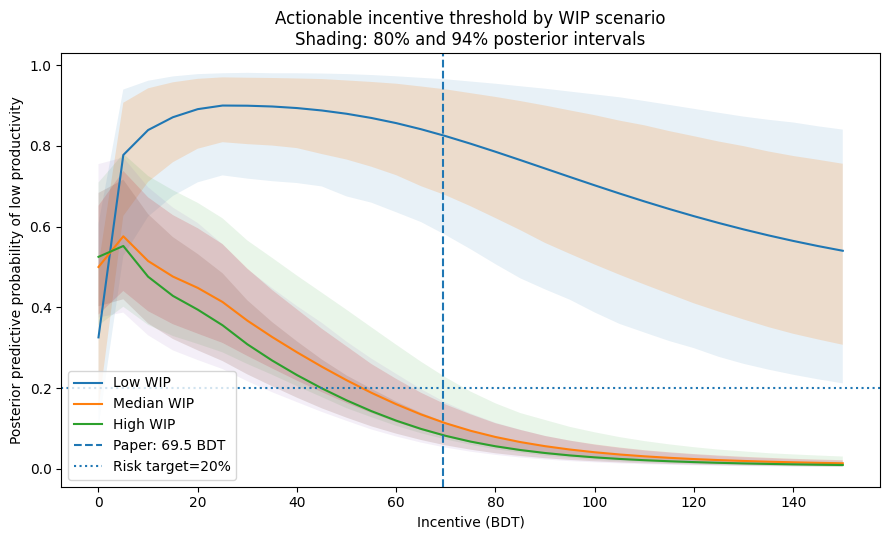

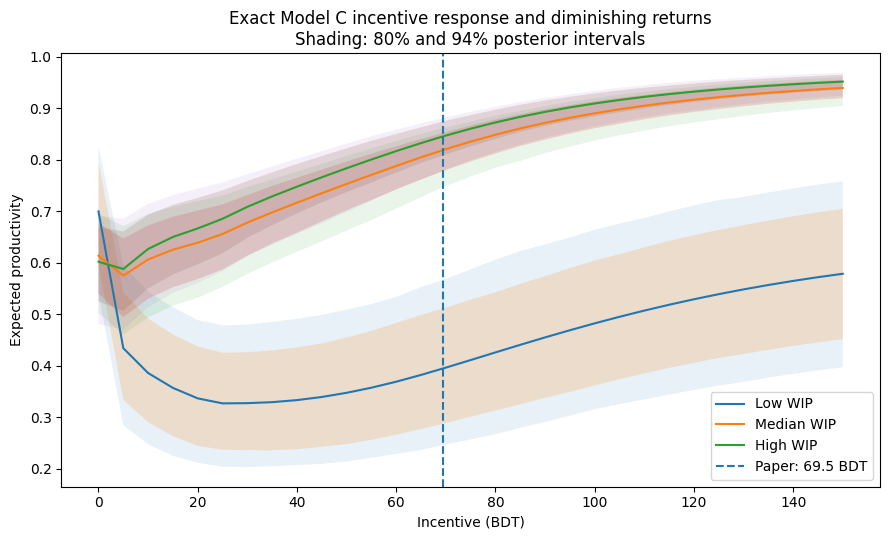

In [14]:
# ── Actionable incentive threshold with posterior uncertainty ─────────────────

# Average policy curves over a representative panel of held-out rows.
panel = (
    base
    .sample(
        n=min(120, len(base)),
        random_state=RANDOM_SEED,
    )
    .reset_index(drop=True)
)

fit_frame = df.iloc[fit_indices].copy()

wip_levels = np.quantile(
    fit_frame["wip_imputed"],
    [0.25, 0.50, 0.75],
)

wip_names = [
    "Low WIP",
    "Median WIP",
    "High WIP",
]

incentive_grid = np.arange(
    0.0,
    155.0,
    5.0,
)

curve_rows = []
posterior_threshold_rows = []
threshold_draw_rows = []

for wip_name, wip_level in zip(
    wip_names,
    wip_levels,
):
    risk_grid_draws = []
    productivity_grid_draws = []

    for incentive_value in incentive_grid:
        scenario = panel.copy()
        scenario["incentive"] = incentive_value
        scenario["wip_imputed"] = wip_level
        scenario["wip_missing_flag"] = 0

        mu_s, nu_s = model_c_mu_draws(
            scenario,
            population_average_team=False,
        )

        risk_s = low_risk_draws(
            mu_s,
            scenario[
                "targeted_productivity"
            ].to_numpy(float),
            nu_s,
        )

        mean_productivity_draw = mu_s.mean(axis=1)
        mean_risk_draw = risk_s.mean(axis=1)

        productivity_grid_draws.append(
            mean_productivity_draw
        )
        risk_grid_draws.append(
            mean_risk_draw
        )

        curve_rows.append({
            "wip_scenario": wip_name,
            "wip_pieces": wip_level,
            "incentive_bdt": incentive_value,
            "expected_productivity": (
                mean_productivity_draw.mean()
            ),
            "productivity_p03": np.quantile(
                mean_productivity_draw,
                0.03,
            ),
            "productivity_p10": np.quantile(
                mean_productivity_draw,
                0.10,
            ),
            "productivity_p90": np.quantile(
                mean_productivity_draw,
                0.90,
            ),
            "productivity_p97": np.quantile(
                mean_productivity_draw,
                0.97,
            ),
            "low_risk": mean_risk_draw.mean(),
            "risk_p03": np.quantile(
                mean_risk_draw,
                0.03,
            ),
            "risk_p10": np.quantile(
                mean_risk_draw,
                0.10,
            ),
            "risk_p90": np.quantile(
                mean_risk_draw,
                0.90,
            ),
            "risk_p97": np.quantile(
                mean_risk_draw,
                0.97,
            ),
        })

    # Draw x incentive-grid matrices.
    risk_matrix = np.column_stack(
        risk_grid_draws
    )
    productivity_matrix = np.column_stack(
        productivity_grid_draws
    )

    threshold_samples = np.full(
        risk_matrix.shape[0],
        np.nan,
        dtype=float,
    )

    for draw_index, draw_risk in enumerate(
        risk_matrix
    ):
        crossing = np.flatnonzero(
            draw_risk <= RISK_TARGET
        )

        if len(crossing):
            threshold_samples[draw_index] = (
                incentive_grid[crossing[0]]
            )

        threshold_draw_rows.append({
            "wip_scenario": wip_name,
            "wip_pieces": wip_level,
            "posterior_draw": draw_index,
            "threshold_bdt": (
                threshold_samples[draw_index]
            ),
        })

    valid_thresholds = threshold_samples[
        np.isfinite(threshold_samples)
    ]

    if len(valid_thresholds):
        threshold_80 = np.quantile(
            valid_thresholds,
            [0.10, 0.90],
        )
        threshold_94 = np.quantile(
            valid_thresholds,
            [0.03, 0.97],
        )
        threshold_median = np.median(
            valid_thresholds
        )
        threshold_mean = np.mean(
            valid_thresholds
        )
        paper_in_94 = bool(
            threshold_94[0]
            <= PAPER_INCENTIVE_THRESHOLD
            <= threshold_94[1]
        )
        comparison = (
            "Paper 69.5 BDT lies inside "
            "the 94% posterior threshold interval"
            if paper_in_94
            else "Paper 69.5 BDT lies outside "
            "the 94% posterior threshold interval"
        )
    else:
        threshold_80 = [np.nan, np.nan]
        threshold_94 = [np.nan, np.nan]
        threshold_median = np.nan
        threshold_mean = np.nan
        paper_in_94 = False
        comparison = (
            "Risk target was not reached "
            "within the incentive grid"
        )

    posterior_threshold_rows.append({
        "wip_scenario": wip_name,
        "wip_pieces": wip_level,
        "risk_target": RISK_TARGET,
        "threshold_mean_bdt": threshold_mean,
        "threshold_median_bdt": (
            threshold_median
        ),
        "threshold_p10_bdt": threshold_80[0],
        "threshold_p90_bdt": threshold_80[1],
        "threshold_p03_bdt": threshold_94[0],
        "threshold_p97_bdt": threshold_94[1],
        "posterior_crossing_rate": (
            len(valid_thresholds)
            / len(threshold_samples)
        ),
        "paper_threshold_bdt": (
            PAPER_INCENTIVE_THRESHOLD
        ),
        "paper_inside_94_interval": paper_in_94,
        "comparison": comparison,
    })

threshold_curves = pd.DataFrame(curve_rows)

threshold_curves.to_csv(
    OUTPUT_DIR
    / "validation_incentive_threshold_curves.csv",
    index=False,
)

posterior_threshold_summary = pd.DataFrame(
    posterior_threshold_rows
)

posterior_threshold_summary.to_csv(
    OUTPUT_DIR
    / "validation_actionable_threshold_posterior.csv",
    index=False,
)

threshold_draws = pd.DataFrame(
    threshold_draw_rows
)

threshold_draws.to_csv(
    OUTPUT_DIR
    / "validation_actionable_threshold_draws.csv",
    index=False,
)

# Mean-curve threshold and diminishing-return diagnostics.
threshold_rows = []

for scenario_name, sub in threshold_curves.groupby(
    "wip_scenario",
    sort=False,
):
    sub = sub.sort_values(
        "incentive_bdt"
    ).reset_index(drop=True)

    feasible = sub.loc[
        sub["low_risk"] <= RISK_TARGET
    ]

    mean_curve_threshold = (
        feasible["incentive_bdt"].min()
        if len(feasible)
        else np.nan
    )

    paper_row = sub.iloc[
        (
            sub["incentive_bdt"]
            - PAPER_INCENTIVE_THRESHOLD
        ).abs().argmin()
    ]

    marginal = np.gradient(
        sub[
            "expected_productivity"
        ].to_numpy(float),
        sub["incentive_bdt"].to_numpy(float),
    )

    max_marginal = np.nanmax(marginal)

    diminishing_candidates = sub.loc[
        (
            sub["incentive_bdt"] >= 10
        )
        & (
            marginal
            <= 0.25 * max_marginal
        ),
        "incentive_bdt",
    ]

    diminishing = (
        diminishing_candidates.min()
        if len(diminishing_candidates)
        else np.nan
    )

    posterior_row = (
        posterior_threshold_summary.loc[
            posterior_threshold_summary[
                "wip_scenario"
            ].eq(scenario_name)
        ]
        .iloc[0]
    )

    threshold_rows.append({
        "wip_scenario": scenario_name,
        "wip_pieces": sub["wip_pieces"].iloc[0],
        "mean_curve_minimum_incentive_for_risk_target": (
            mean_curve_threshold
        ),
        "posterior_threshold_median_bdt": (
            posterior_row[
                "threshold_median_bdt"
            ]
        ),
        "posterior_threshold_p03_bdt": (
            posterior_row[
                "threshold_p03_bdt"
            ]
        ),
        "posterior_threshold_p97_bdt": (
            posterior_row[
                "threshold_p97_bdt"
            ]
        ),
        "posterior_crossing_rate": (
            posterior_row[
                "posterior_crossing_rate"
            ]
        ),
        "risk_near_69_5_bdt": (
            paper_row["low_risk"]
        ),
        "expected_productivity_near_69_5_bdt": (
            paper_row[
                "expected_productivity"
            ]
        ),
        "diminishing_returns_candidate_bdt": (
            diminishing
        ),
        "paper_threshold_bdt": (
            PAPER_INCENTIVE_THRESHOLD
        ),
        "paper_inside_94_interval": (
            posterior_row[
                "paper_inside_94_interval"
            ]
        ),
    })

threshold_summary = pd.DataFrame(
    threshold_rows
)

threshold_summary.to_csv(
    OUTPUT_DIR / "validation_actionable_thresholds.csv",
    index=False,
)

display(posterior_threshold_summary)
display(threshold_summary)

# Risk curves with posterior uncertainty.
plt.figure(figsize=(9, 5.5))

for scenario_name, sub in threshold_curves.groupby(
    "wip_scenario",
    sort=False,
):
    sub = sub.sort_values("incentive_bdt")
    x = sub["incentive_bdt"].to_numpy(float)

    plt.fill_between(
        x,
        sub["risk_p03"].to_numpy(float),
        sub["risk_p97"].to_numpy(float),
        alpha=0.10,
    )
    plt.fill_between(
        x,
        sub["risk_p10"].to_numpy(float),
        sub["risk_p90"].to_numpy(float),
        alpha=0.18,
    )
    plt.plot(
        x,
        sub["low_risk"].to_numpy(float),
        label=scenario_name,
    )

plt.axvline(
    PAPER_INCENTIVE_THRESHOLD,
    linestyle="--",
    label="Paper: 69.5 BDT",
)
plt.axhline(
    RISK_TARGET,
    linestyle=":",
    label=f"Risk target={RISK_TARGET:.0%}",
)
plt.xlabel("Incentive (BDT)")
plt.ylabel(
    "Posterior predictive probability "
    "of low productivity"
)
plt.title(
    "Actionable incentive threshold by WIP scenario\n"
    "Shading: 80% and 94% posterior intervals"
)
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "validation_incentive_threshold.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

# Expected productivity curves with posterior uncertainty.
plt.figure(figsize=(9, 5.5))

for scenario_name, sub in threshold_curves.groupby(
    "wip_scenario",
    sort=False,
):
    sub = sub.sort_values("incentive_bdt")
    x = sub["incentive_bdt"].to_numpy(float)

    plt.fill_between(
        x,
        sub[
            "productivity_p03"
        ].to_numpy(float),
        sub[
            "productivity_p97"
        ].to_numpy(float),
        alpha=0.10,
    )
    plt.fill_between(
        x,
        sub[
            "productivity_p10"
        ].to_numpy(float),
        sub[
            "productivity_p90"
        ].to_numpy(float),
        alpha=0.18,
    )
    plt.plot(
        x,
        sub[
            "expected_productivity"
        ].to_numpy(float),
        label=scenario_name,
    )

plt.axvline(
    PAPER_INCENTIVE_THRESHOLD,
    linestyle="--",
    label="Paper: 69.5 BDT",
)
plt.xlabel("Incentive (BDT)")
plt.ylabel("Expected productivity")
plt.title(
    "Exact Model C incentive response and diminishing returns\n"
    "Shading: 80% and 94% posterior intervals"
)
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR
    / "validation_incentive_productivity_curve.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()


## 12. Missing-WIP sensitivity analysis

In [15]:
missing_test = base[pd.to_numeric(base["wip_missing_flag"], errors="coerce").fillna(0).eq(1)].copy()
if len(missing_test):
    current = missing_test.copy()
    zero_wip = missing_test.copy()
    zero_wip["wip_imputed"] = 0.0

    dept_median = fit_frame.groupby("dept_bin")["wip_imputed"].median()
    median_wip = missing_test.copy()
    median_wip["wip_imputed"] = median_wip["dept_bin"].map(dept_median).fillna(fit_frame["wip_imputed"].median())

    sensitivity_rows = []
    scenario_predictions = {}
    for name, frame in {
        "Model C cleaned/imputed value": current,
        "Sensitivity: WIP = 0": zero_wip,
        "Sensitivity: department median WIP": median_wip,
    }.items():
        mu_s, nu_s = model_c_mu_draws(frame)
        risk_s = low_risk_draws(mu_s, frame["targeted_productivity"].to_numpy(float), nu_s)
        scenario_predictions[name] = mu_s
        sensitivity_rows.append({
            "scenario": name,
            "n_missing_wip_test_rows": len(frame),
            "mean_expected_productivity": mu_s.mean(),
            "mean_low_risk": risk_s.mean(),
        })

    wip_sensitivity = pd.DataFrame(sensitivity_rows)
    wip_sensitivity.to_csv(OUTPUT_DIR / "validation_missing_wip_sensitivity.csv", index=False)
    display(wip_sensitivity)
else:
    wip_sensitivity = pd.DataFrame()
    print("No missing-WIP rows occur in the exact Model C test split.")

,scenario,n_missing_wip_test_rows,mean_expected_productivity,mean_low_risk
0,Model C cleaned/imputed value,146,0.774728,0.178086
1,Sensitivity: WIP = 0,146,0.774728,0.178086
2,Sensitivity: department median WIP,146,0.774728,0.178086


## 13. Offline budget allocation using posterior expected uplift

,budget_bdt,number_of_allocations,greedy_expected_total_uplift,greedy_total_uplift_p10,greedy_total_uplift_p90,random_expected_total_uplift_mean,random_expected_total_uplift_p95,probability_greedy_beats_random_draw
0,720.0,72,3.476714,2.967023,3.975758,-7.659015,-5.524787,1.0


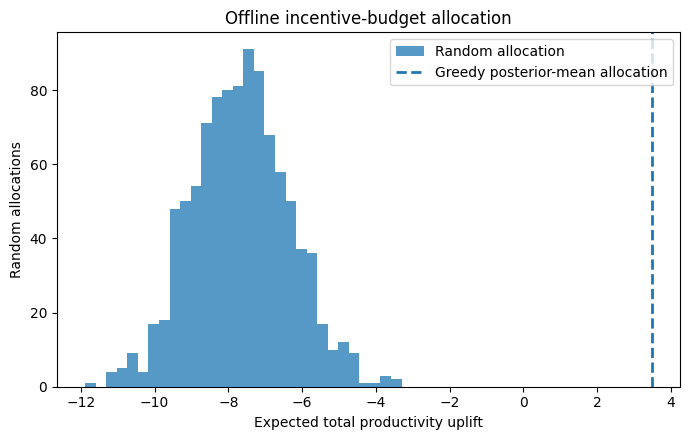

In [16]:
# This is a model-based offline policy simulation, not a causal estimate.
budget_increment = 10.0
budget_scenario = base.copy()
budget_scenario["incentive"] = budget_scenario["incentive"] + budget_increment
mu_budget, _ = model_c_mu_draws(budget_scenario)
uplift_budget = mu_budget - mu_base
mean_uplift_budget = uplift_budget.mean(axis=0)

n_slots = max(1, int(np.ceil(0.20 * len(base))))
greedy_idx = np.argsort(mean_uplift_budget)[-n_slots:]
greedy_total_draw = uplift_budget[:, greedy_idx].sum(axis=1)

random_totals = []
for _ in range(BOOTSTRAP_REPS):
    idx = rng.choice(len(base), n_slots, replace=False)
    random_totals.append(uplift_budget[:, idx].mean(axis=0).sum())
random_totals = np.asarray(random_totals)

allocation = pd.DataFrame({
    "original_row_index": base["original_row_index"].to_numpy(int),
    "team": base["team"].to_numpy(),
    "current_incentive": base["incentive"].to_numpy(float),
    "increment_bdt": budget_increment,
    "mean_expected_uplift": mean_uplift_budget,
    "selected_by_greedy": False,
})
allocation.loc[greedy_idx, "selected_by_greedy"] = True
allocation = allocation.sort_values("mean_expected_uplift", ascending=False)
allocation.to_csv(OUTPUT_DIR / "validation_budget_allocation.csv", index=False)

allocation_summary = pd.DataFrame([{
    "budget_bdt": budget_increment * n_slots,
    "number_of_allocations": n_slots,
    "greedy_expected_total_uplift": greedy_total_draw.mean(),
    "greedy_total_uplift_p10": np.quantile(greedy_total_draw, 0.10),
    "greedy_total_uplift_p90": np.quantile(greedy_total_draw, 0.90),
    "random_expected_total_uplift_mean": random_totals.mean(),
    "random_expected_total_uplift_p95": np.quantile(random_totals, 0.95),
    "probability_greedy_beats_random_draw": np.mean(greedy_total_draw.mean() > random_totals),
}])
allocation_summary.to_csv(OUTPUT_DIR / "validation_budget_allocation_summary.csv", index=False)
display(allocation_summary)

plt.figure(figsize=(7, 4.5))
plt.hist(random_totals, bins=30, alpha=0.75, label="Random allocation")
plt.axvline(greedy_total_draw.mean(), linestyle="--", linewidth=2, label="Greedy posterior-mean allocation")
plt.xlabel("Expected total productivity uplift")
plt.ylabel("Random allocations")
plt.title("Offline incentive-budget allocation")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "validation_budget_utility.png", dpi=160, bbox_inches="tight")
plt.show()

## 14. Kalman temporal validation, calendar effects, and style-change drift

Using Kalman forecast file:
/content/ProdFusion/models/03_v7_1_forecasts.csv
✓ Kalman rows aligned: 1197


,model,split,n,mae,rmse,r2,bias_pred_minus_actual,mean_interval_width80,mean_interval_width95,coverage80,coverage95,paper_low_auc,paper_low_ap,paper_low_brier,paper_3class_accuracy
0,Kalman DLM v7.1 final forecast,future temporal test,192,0.085974,0.131608,0.278457,-0.000389,0.347142,0.591682,0.885417,0.979167,0.715432,0.347646,0.127182,0.765625


,style_change_flag,n,mean_actual,mean_forecast,mean_abs_standardized_innovation,change_point_rate,mannwhitney_pvalue
0,0,272,0.717388,0.743499,0.696777,0.073529,0.559422
1,1,102,0.649019,0.627252,0.690797,0.068627,0.559422


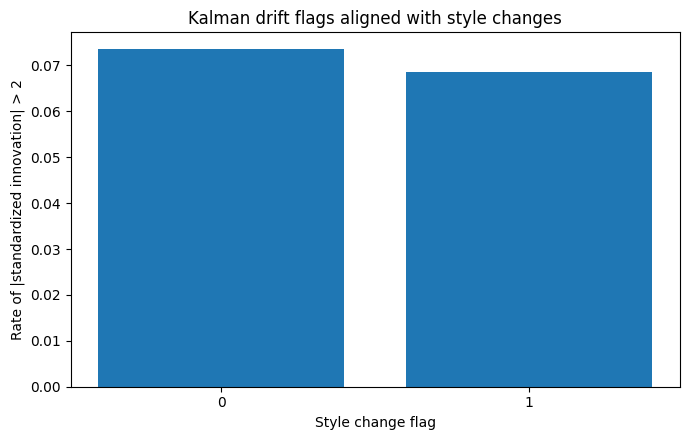

In [17]:
# ── Validate the exact corrected Kalman DLM v7.1 output ───────────────────────

kalman_metrics = pd.DataFrame()
kalman_merged = pd.DataFrame()
kalman_test = pd.DataFrame()

# Exact forecast file created by:
# 03_kalman_dlm_v7_1_corrected_colab (1).ipynb
KALMAN_FORECAST_PATH = MODEL_DIR / "03_v7_1_forecasts.csv"

if not KALMAN_FORECAST_PATH.exists():
    raise FileNotFoundError(
        "The corrected Kalman forecast file was not found:\n"
        f"{KALMAN_FORECAST_PATH}\n\n"
        "Run the Kalman notebook through Section 12.1 and push "
        "models/03_v7_1_forecasts.csv to GitHub."
    )

print("Using Kalman forecast file:")
print(KALMAN_FORECAST_PATH)

# ── 1. Load the exact Kalman v7.1 forecasts ───────────────────────────────────

kf = pd.read_csv(KALMAN_FORECAST_PATH)
kf.columns = kf.columns.str.strip()

required_k = [
    "team_dept_idx",
    "team",
    "dept_bin",
    "date",
    "t",
    "split_code",
    "actual_y",
    "y_pred",
    "pred_sd_raw",
    "innovation",
    "innovation_std",
    "y_lo80",
    "y_hi80",
    "y_lo95",
    "y_hi95",
]

missing_k = [column for column in required_k if column not in kf.columns]

if missing_k:
    raise KeyError(
        "03_v7_1_forecasts.csv is missing these required columns:\n"
        + "\n".join(f"  - {column}" for column in missing_k)
    )

kf["date"] = pd.to_datetime(kf["date"], errors="raise")

for column in [
    "team_dept_idx",
    "team",
    "dept_bin",
    "t",
    "split_code",
]:
    kf[column] = pd.to_numeric(
        kf[column],
        errors="raise",
    ).astype(int)

for column in [
    "actual_y",
    "y_pred",
    "pred_sd_raw",
    "innovation",
    "innovation_std",
    "y_lo80",
    "y_hi80",
    "y_lo95",
    "y_hi95",
]:
    kf[column] = pd.to_numeric(
        kf[column],
        errors="coerce",
    )

# ── 2. Prepare the Bayesian/cleaned data only for row alignment ───────────────

data_for_merge = df.copy()

if "original_row_index" not in data_for_merge.columns:
    data_for_merge["original_row_index"] = np.arange(
        len(data_for_merge),
        dtype=int,
    )

if "date" in data_for_merge.columns:
    data_for_merge["date"] = pd.to_datetime(
        data_for_merge["date"],
        errors="coerce",
    )

for column in [
    "team_dept_idx",
    "team",
    "dept_bin",
    "t",
]:
    if column in data_for_merge.columns:
        data_for_merge[column] = pd.to_numeric(
            data_for_merge[column],
            errors="coerce",
        ).astype("Int64")

# Reconstruct raw variables when only log variables are available.
if "incentive" not in data_for_merge.columns:
    data_for_merge["incentive"] = np.expm1(
        pd.to_numeric(
            data_for_merge["log_incentive"],
            errors="coerce",
        )
    )

if "wip_imputed" not in data_for_merge.columns:
    data_for_merge["wip_imputed"] = np.expm1(
        pd.to_numeric(
            data_for_merge["log_wip_imputed"],
            errors="coerce",
        )
    )

if "no_of_workers" not in data_for_merge.columns:
    data_for_merge["no_of_workers"] = np.expm1(
        pd.to_numeric(
            data_for_merge["log_workers"],
            errors="coerce",
        )
    )

# Create paper-compatible classes if not already available.
if "class3_paper" not in data_for_merge.columns:
    actual_raw = pd.to_numeric(
        data_for_merge["actual_productivity"],
        errors="coerce",
    )

    target_raw = pd.to_numeric(
        data_for_merge["targeted_productivity"],
        errors="coerce",
    ).replace(0, np.nan)

    achievement = (
        actual_raw / target_raw
    ).replace(
        [np.inf, -np.inf],
        np.nan,
    ).fillna(0.0)

    data_for_merge["class3_paper"] = np.select(
        [
            achievement < LOW_ACHIEVEMENT,
            achievement < NORMAL_ACHIEVEMENT,
        ],
        [0, 1],
        default=2,
    ).astype(int)

if "low_paper" not in data_for_merge.columns:
    data_for_merge["low_paper"] = (
        data_for_merge["class3_paper"] == 0
    ).astype(int)

# team_dept_idx + t is the exact unique key used by the Kalman notebook.
merge_cols = ["team_dept_idx", "t"]

if not set(merge_cols).issubset(data_for_merge.columns):
    merge_cols = ["date", "team", "dept_bin", "t"]

if data_for_merge.duplicated(merge_cols).any():
    duplicates = data_for_merge.loc[
        data_for_merge.duplicated(
            merge_cols,
            keep=False,
        ),
        merge_cols,
    ].head(10)

    raise RuntimeError(
        "The cleaned dataset is not unique using the Kalman keys:\n"
        f"{duplicates}"
    )

carry_candidates = [
    "original_row_index",
    "actual_productivity",
    "targeted_productivity",
    "class3_paper",
    "low_paper",
    "no_of_style_change",
    "incentive",
    "wip_imputed",
    "no_of_workers",
    "quarter",
    "day_num",
    "sin_dow",
    "cos_dow",
]

carry_cols = merge_cols.copy()

for column in carry_candidates:
    if (
        column in data_for_merge.columns
        and column not in carry_cols
    ):
        carry_cols.append(column)

kalman_merged = kf.merge(
    data_for_merge[carry_cols],
    on=merge_cols,
    how="left",
    validate="many_to_one",
)

if kalman_merged["original_row_index"].isna().any():
    unmatched = kalman_merged.loc[
        kalman_merged["original_row_index"].isna(),
        ["team_dept_idx", "team", "dept_bin", "date", "t"],
    ].head(10)

    raise RuntimeError(
        "Some Kalman rows could not be matched to the cleaned dataset:\n"
        f"{unmatched}"
    )

kalman_merged["original_row_index"] = (
    kalman_merged["original_row_index"].astype(int)
)

# Verify that the Kalman target matches the original, un-clipped target.
if "actual_productivity" in kalman_merged.columns:
    target_difference = np.abs(
        pd.to_numeric(
            kalman_merged["actual_productivity"],
            errors="coerce",
        )
        - kalman_merged["actual_y"]
    )

    if target_difference.max() > 1e-6:
        raise RuntimeError(
            "Kalman actual_y does not match actual_productivity. "
            f"Maximum difference: {target_difference.max():.8f}"
        )

print(
    "✓ Kalman rows aligned:",
    len(kalman_merged),
)

# ── 3. Convert Kalman forecasts into paper-compatible probabilities ───────────

sd = pd.to_numeric(
    kalman_merged["pred_sd_raw"],
    errors="coerce",
)

if sd.isna().all():
    residual_sd = np.std(
        kalman_merged["actual_y"]
        - kalman_merged["y_pred"]
    )

    sd = pd.Series(
        residual_sd,
        index=kalman_merged.index,
    )

sd = (
    sd
    .fillna(sd.median())
    .clip(lower=1e-6)
)

kalman_merged["paper_p_low"] = stats.norm.cdf(
    (
        LOW_ACHIEVEMENT
        * kalman_merged["targeted_productivity"]
        - kalman_merged["y_pred"]
    )
    / sd
)

cdf_below_normal = stats.norm.cdf(
    (
        NORMAL_ACHIEVEMENT
        * kalman_merged["targeted_productivity"]
        - kalman_merged["y_pred"]
    )
    / sd
)

kalman_merged["paper_p_moderate"] = np.clip(
    cdf_below_normal
    - kalman_merged["paper_p_low"],
    0.0,
    1.0,
)

kalman_merged["paper_p_normal"] = np.clip(
    1.0 - cdf_below_normal,
    0.0,
    1.0,
)

probability_columns = [
    "paper_p_low",
    "paper_p_moderate",
    "paper_p_normal",
]

probability_total = (
    kalman_merged[probability_columns]
    .sum(axis=1)
    .replace(0, 1)
)

kalman_merged[probability_columns] = (
    kalman_merged[probability_columns]
    .div(probability_total, axis=0)
)

# ── 4. Temporal test metrics ──────────────────────────────────────────────────

kalman_test = kalman_merged.loc[
    kalman_merged["split_code"].eq(2)
].copy()

if kalman_test.empty:
    raise RuntimeError(
        "No Kalman temporal test rows were found with split_code == 2."
    )

y = kalman_test["actual_y"].to_numpy(dtype=float)
y_pred = kalman_test["y_pred"].to_numpy(dtype=float)

probs_k = kalman_test[
    probability_columns
].to_numpy(dtype=float)

predicted_class3 = np.argmax(
    probs_k,
    axis=1,
)

low_true = kalman_test["low_paper"].astype(int)

if low_true.nunique() == 2:
    low_auc = safe_auc_binary(
        low_true,
        kalman_test["paper_p_low"],
    )

    low_ap = average_precision_score(
        low_true,
        kalman_test["paper_p_low"],
    )

    low_brier = brier_score_loss(
        low_true,
        kalman_test["paper_p_low"],
    )
else:
    low_auc = np.nan
    low_ap = np.nan
    low_brier = np.nan

kalman_metrics = pd.DataFrame([{
    "model": "Kalman DLM v7.1 final forecast",
    "split": "future temporal test",
    "n": len(kalman_test),
    "mae": mean_absolute_error(y, y_pred),
    "rmse": mean_squared_error(y, y_pred) ** 0.5,
    "r2": r2_score(y, y_pred),
    "bias_pred_minus_actual": float(np.mean(y_pred - y)),
    "mean_interval_width80": float(
        np.mean(
            kalman_test["y_hi80"]
            - kalman_test["y_lo80"]
        )
    ),
    "mean_interval_width95": float(
        np.mean(
            kalman_test["y_hi95"]
            - kalman_test["y_lo95"]
        )
    ),
    "coverage80": np.mean(
        (y >= kalman_test["y_lo80"])
        & (y <= kalman_test["y_hi80"])
    ),
    "coverage95": np.mean(
        (y >= kalman_test["y_lo95"])
        & (y <= kalman_test["y_hi95"])
    ),
    "paper_low_auc": low_auc,
    "paper_low_ap": low_ap,
    "paper_low_brier": low_brier,
    "paper_3class_accuracy": accuracy_score(
        kalman_test["class3_paper"],
        predicted_class3,
    ),
}])

kalman_metrics.to_csv(
    OUTPUT_DIR / "validation_kalman_temporal_metrics.csv",
    index=False,
)

kalman_merged.to_csv(
    OUTPUT_DIR / "validation_kalman_aligned_forecasts.csv",
    index=False,
)

display(kalman_metrics)

# ── 5. Calendar and style-change drift diagnostics ────────────────────────────

analysis_k = kalman_merged.loc[
    kalman_merged["split_code"].isin([1, 2])
].copy()

analysis_k["forecast_error"] = (
    analysis_k["actual_y"]
    - analysis_k["y_pred"]
)

analysis_k["abs_innovation_std"] = (
    pd.to_numeric(
        analysis_k["innovation_std"],
        errors="coerce",
    )
    .abs()
)

analysis_k["change_point_flag"] = (
    analysis_k["abs_innovation_std"] > 2.0
).astype(int)

analysis_k["style_change_flag"] = (
    pd.to_numeric(
        analysis_k["no_of_style_change"],
        errors="coerce",
    )
    .fillna(0)
    > 0
).astype(int)

analysis_k["weekday"] = (
    pd.to_datetime(
        analysis_k["date"],
        errors="coerce",
    )
    .dt.day_name()
)

analysis_k["month_day"] = (
    pd.to_datetime(
        analysis_k["date"],
        errors="coerce",
    )
    .dt.day
)

analysis_k["quarter_of_month"] = pd.cut(
    analysis_k["month_day"],
    bins=[0, 7, 14, 21, 31],
    labels=["Q1", "Q2", "Q3", "Q4"],
)

calendar_table = (
    analysis_k
    .groupby(
        ["weekday", "quarter_of_month"],
        observed=True,
    )
    .agg(
        n=("actual_y", "size"),
        mean_error=("forecast_error", "mean"),
        mean_abs_standardized_innovation=(
            "abs_innovation_std",
            "mean",
        ),
        change_point_rate=(
            "change_point_flag",
            "mean",
        ),
    )
    .reset_index()
)

calendar_table.to_csv(
    OUTPUT_DIR / "validation_calendar_effects.csv",
    index=False,
)

style_table = (
    analysis_k
    .groupby("style_change_flag")
    .agg(
        n=("actual_y", "size"),
        mean_actual=("actual_y", "mean"),
        mean_forecast=("y_pred", "mean"),
        mean_abs_standardized_innovation=(
            "abs_innovation_std",
            "mean",
        ),
        change_point_rate=(
            "change_point_flag",
            "mean",
        ),
    )
    .reset_index()
)

if analysis_k["style_change_flag"].nunique() == 2:
    style_change_innovations = analysis_k.loc[
        analysis_k["style_change_flag"].eq(1),
        "abs_innovation_std",
    ].dropna()

    no_style_change_innovations = analysis_k.loc[
        analysis_k["style_change_flag"].eq(0),
        "abs_innovation_std",
    ].dropna()

    if (
        len(style_change_innovations) > 0
        and len(no_style_change_innovations) > 0
    ):
        test_result = stats.mannwhitneyu(
            style_change_innovations,
            no_style_change_innovations,
            alternative="two-sided",
        )

        style_table["mannwhitney_pvalue"] = (
            test_result.pvalue
        )

style_table.to_csv(
    OUTPUT_DIR / "validation_style_change_drift.csv",
    index=False,
)

display(style_table)

plt.figure(figsize=(7, 4.5))

plt.bar(
    style_table["style_change_flag"].astype(str),
    style_table["change_point_rate"],
)

plt.xlabel("Style change flag")
plt.ylabel("Rate of |standardized innovation| > 2")
plt.title("Kalman drift flags aligned with style changes")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "validation_style_change_drift.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

## 15. Bayesian + Kalman combined validation on the dual-holdout intersection

,model,task,decision_rule,decision_threshold,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,low_precision,low_recall,low_f1,specificity,auc,average_precision,brier,ece_10bin,log_loss,false_negatives,false_positives,expected_cost,n
0,Bayesian Model C — dual holdout,3-class,argmax posterior probability,NaN,0.767857,0.339286,0.333333,0.339286,0.336279,0.760125,0.142857,0.142857,0.142857,NaN,0.463448,NaN,NaN,NaN,0.679042,NaN,NaN,NaN,56
1,Kalman — dual holdout,3-class,argmax posterior probability,NaN,0.821429,0.441468,0.441468,0.441468,0.441468,0.821429,0.428571,0.428571,0.428571,NaN,0.642695,NaN,NaN,NaN,0.577120,NaN,NaN,NaN,56
2,Bayesian + Kalman equal-weight ensemble,3-class,argmax posterior probability,NaN,0.821429,0.360119,0.371795,0.360119,0.360606,0.794156,0.250000,0.142857,0.181818,NaN,0.584131,NaN,NaN,NaN,0.612779,NaN,NaN,NaN,56
3,Bayesian Model C — dual holdout,2-class,P(low) ≥ 0.333,0.333333,0.625000,0.418367,0.456250,0.418367,0.425501,0.679409,0.062500,0.142857,0.086957,0.693878,0.472303,0.146124,0.151174,0.167280,0.474677,6.0,15.0,27.0,56
4,Kalman — dual holdout,2-class,P(low) ≥ 0.333,0.333333,0.821429,0.653061,0.624113,0.653061,0.635417,0.830729,0.333333,0.428571,0.375000,0.877551,0.752187,0.455825,0.101052,0.086801,0.337752,4.0,6.0,14.0,56
5,Bayesian + Kalman equal-weight ensemble,2-class,P(low) ≥ 0.333,0.333333,0.767857,0.683673,0.607143,0.683673,0.619048,0.797619,0.285714,0.571429,0.380952,0.795918,0.667638,0.244987,0.119280,0.101639,0.392934,3.0,10.0,16.0,56


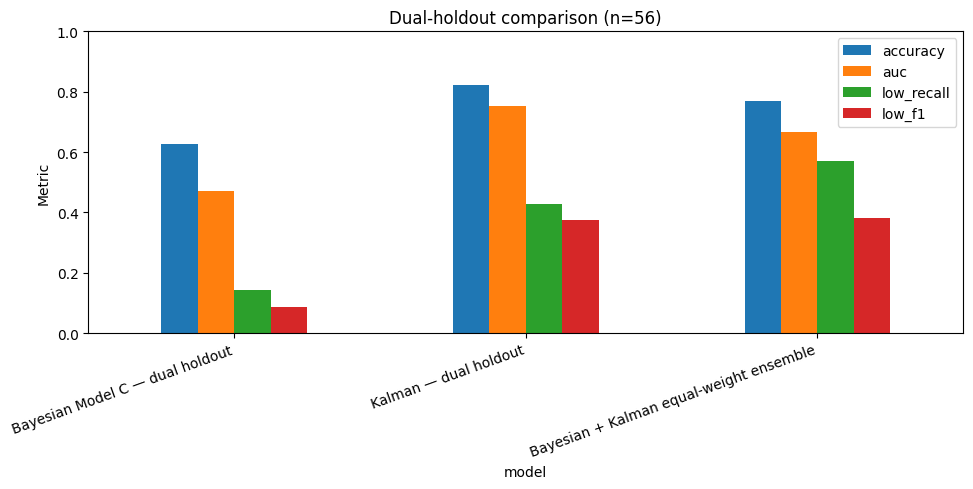

In [18]:
dual_metrics = pd.DataFrame()
dual_decisions = pd.DataFrame()

if len(kalman_test):
    kcols = [
        "original_row_index", "class3_paper", "low_paper",
        "paper_p_low", "paper_p_moderate", "paper_p_normal",
        "y_pred", "actual_y",
    ]
    dual = bayes_pred_df.merge(
        kalman_test[kcols], on="original_row_index", how="inner", suffixes=("_bayes", "_kalman")
    )
    if len(dual):
        bayes_probs = dual[["p_low", "p_moderate", "p_normal"]].to_numpy(float)
        kalman_probs = dual[["paper_p_low", "paper_p_moderate", "paper_p_normal"]].to_numpy(float)
        ensemble_probs = 0.5 * bayes_probs + 0.5 * kalman_probs
        ensemble_probs = ensemble_probs / ensemble_probs.sum(axis=1, keepdims=True)
        y3 = dual["actual_class3"].to_numpy(int)
        y2 = dual["actual_low"].to_numpy(int)

        dual_rows = [
            metrics_3class(y3, bayes_probs, "Bayesian Model C — dual holdout"),
            metrics_3class(y3, kalman_probs, "Kalman — dual holdout"),
            metrics_3class(y3, ensemble_probs, "Bayesian + Kalman equal-weight ensemble"),
            metrics_binary(y2, bayes_probs[:, 0], COST_THRESHOLD, "Bayesian Model C — dual holdout"),
            metrics_binary(y2, kalman_probs[:, 0], COST_THRESHOLD, "Kalman — dual holdout"),
            metrics_binary(y2, ensemble_probs[:, 0], COST_THRESHOLD, "Bayesian + Kalman equal-weight ensemble"),
        ]
        dual_metrics = pd.DataFrame(dual_rows)
        dual_metrics.to_csv(OUTPUT_DIR / "validation_dual_holdout_metrics.csv", index=False)

        dual_decisions = dual.copy()
        dual_decisions["ensemble_p_low"] = ensemble_probs[:, 0]
        dual_decisions["ensemble_p_moderate"] = ensemble_probs[:, 1]
        dual_decisions["ensemble_p_normal"] = ensemble_probs[:, 2]
        dual_decisions["ensemble_class3"] = np.argmax(ensemble_probs, axis=1)
        dual_decisions["ensemble_low_cost"] = (ensemble_probs[:, 0] >= COST_THRESHOLD).astype(int)
        dual_decisions.to_csv(OUTPUT_DIR / "validation_dual_holdout_decisions.csv", index=False)
        display(dual_metrics)

        compare = dual_metrics[dual_metrics["task"].eq("2-class")][["model", "accuracy", "auc", "low_recall", "low_f1"]]
        compare.plot(x="model", y=["accuracy", "auc", "low_recall", "low_f1"], kind="bar", figsize=(10, 5))
        plt.ylim(0, 1)
        plt.ylabel("Metric")
        plt.title(f"Dual-holdout comparison (n={len(dual)})")
        plt.xticks(rotation=20, ha="right")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "validation_dual_holdout_comparison.png", dpi=160, bbox_inches="tight")
        plt.show()
    else:
        print("The paper test and temporal test have no overlapping rows.")
else:
    print("Dual-holdout validation skipped because Kalman forecasts are unavailable.")

## 16. Optional external validation on UCI SECOM

Notebook 05 does not contain an executable SECOM implementation. To avoid claiming an analysis that was not actually run, this upgraded notebook only loads `output/validation/validation_secom_metrics.csv` when that file has been produced by a separate, leakage-safe SECOM workflow.

A proper SECOM extension should use:

- timestamp-ordered train/validation/test blocks;
- train-only imputation, scaling, and feature selection;
- no preprocessing leakage;
- imbalance-aware probability metrics;
- a clearly documented Bayesian classifier and drift update;
- results reported separately from the garment-specific Model C.


In [19]:
# Notebook 05 did not contain an executable SECOM validation section.
# Keep this variable defined so the final summary remains runnable.
# If a separate SECOM validation notebook later writes the expected CSV,
# this notebook will incorporate it automatically.

SECOM_METRICS_PATH = (
    OUTPUT_DIR / "validation_secom_metrics.csv"
)

if SECOM_METRICS_PATH.exists():
    secom_metrics = pd.read_csv(
        SECOM_METRICS_PATH
    )
    print(
        "Loaded external SECOM validation metrics:",
        SECOM_METRICS_PATH,
    )
    display(secom_metrics)
else:
    secom_metrics = pd.DataFrame()
    print(
        "SECOM validation not executed in this notebook. "
        "Notebook 05 contained no SECOM implementation, "
        "so no unverified SECOM result has been imported."
    )


SECOM validation not executed in this notebook. Notebook 05 contained no SECOM implementation, so no unverified SECOM result has been imported.


## 16A. Notebook 05 migration audit

This audit records which Notebook 05 ideas were adopted and which parts were deliberately excluded to protect model identity and validation integrity.


In [20]:
notebook_05_migration_audit = pd.DataFrame([
    {
        "notebook_05_idea": "Paper comparison table",
        "status": "Adopted",
        "implementation_here": (
            "Published paper rows compared with exact Model C "
            "default and cost-sensitive results"
        ),
        "reason": "Improves reporting without changing the model",
    },
    {
        "notebook_05_idea": (
            "Specificity, ECE, false counts, and expected cost"
        ),
        "status": "Adopted",
        "implementation_here": (
            "Computed from exact Model C posterior low probabilities"
        ),
        "reason": (
            "Strengthens imbalance and probability validation"
        ),
    },
    {
        "notebook_05_idea": (
            "Three confusion matrices and benchmark plots"
        ),
        "status": "Adopted",
        "implementation_here": (
            "3-class, binary default, and binary cost-sensitive"
        ),
        "reason": "Clearer comparison with the garment paper",
    },
    {
        "notebook_05_idea": (
            "Incentive contrast at the 69.5 BDT paper rule"
        ),
        "status": "Adopted and corrected",
        "implementation_here": (
            "Exact Model C positive indicator + monotone spline "
            "+ incentive×WIP interaction at median WIP"
        ),
        "reason": (
            "Uses the real fitted specification rather than "
            "a substitute coefficient"
        ),
    },
    {
        "notebook_05_idea": (
            "Posterior threshold uncertainty"
        ),
        "status": "Adopted and expanded",
        "implementation_here": (
            "Posterior threshold distributions by low, median, "
            "and high WIP"
        ),
        "reason": (
            "Avoids reporting only a single mean-curve crossing"
        ),
    },
    {
        "notebook_05_idea": (
            "Scenario productivity and low-risk plots"
        ),
        "status": "Adopted",
        "implementation_here": (
            "Baseline, +20 BDT, −20% WIP, and +5 workers"
        ),
        "reason": "Improves prescriptive interpretation",
    },
    {
        "notebook_05_idea": (
            "Refit a new Bayesian model in validation"
        ),
        "status": "Excluded",
        "implementation_here": (
            "Authoritative Model C posterior and saved draws "
            "are loaded without fitting"
        ),
        "reason": (
            "A refit would no longer be the exact project model"
        ),
    },
    {
        "notebook_05_idea": (
            "Fit a new residual Kalman correction on the paper split"
        ),
        "status": "Excluded",
        "implementation_here": (
            "Corrected saved Kalman v7.1 forecasts are evaluated "
            "on their own temporal test"
        ),
        "reason": (
            "Prevents an unapproved third model and leakage-prone "
            "combined score"
        ),
    },
    {
        "notebook_05_idea": (
            "Silently fall back to old dlm_forecasts.csv"
        ),
        "status": "Excluded",
        "implementation_here": (
            "Only models/03_v7_1_forecasts.csv is accepted"
        ),
        "reason": (
            "The old schema caused incorrect alignment and KeyErrors"
        ),
    },
])

notebook_05_migration_audit.to_csv(
    OUTPUT_DIR
    / "validation_notebook_05_migration_audit.csv",
    index=False,
)

display(notebook_05_migration_audit)


,notebook_05_idea,status,implementation_here,reason
0,Paper comparison table,Adopted,Published paper rows compared with exact Model...,Improves reporting without changing the model
1,"Specificity, ECE, false counts, and expected cost",Adopted,Computed from exact Model C posterior low prob...,Strengthens imbalance and probability validation
2,Three confusion matrices and benchmark plots,Adopted,"3-class, binary default, and binary cost-sensi...",Clearer comparison with the garment paper
3,Incentive contrast at the 69.5 BDT paper rule,Adopted and corrected,Exact Model C positive indicator + monotone sp...,Uses the real fitted specification rather than...
4,Posterior threshold uncertainty,Adopted and expanded,"Posterior threshold distributions by low, medi...",Avoids reporting only a single mean-curve cros...
5,Scenario productivity and low-risk plots,Adopted,"Baseline, +20 BDT, −20% WIP, and +5 workers",Improves prescriptive interpretation
6,Refit a new Bayesian model in validation,Excluded,Authoritative Model C posterior and saved draw...,A refit would no longer be the exact project m...
7,Fit a new residual Kalman correction on the pa...,Excluded,Corrected saved Kalman v7.1 forecasts are eval...,Prevents an unapproved third model and leakage...
8,Silently fall back to old dlm_forecasts.csv,Excluded,Only models/03_v7_1_forecasts.csv is accepted,The old schema caused incorrect alignment and ...


## 17. Objective coverage and scientific-scope audit

In [21]:
coverage_rows = [
    [
        "Exact Bayesian model identity",
        "Covered",
        (
            "Authoritative Model C posterior, metadata, split indices, "
            "and saved predictive draws"
        ),
        "No Bayesian refit occurs in this validation notebook",
    ],
    [
        "Paper 3-class comparison",
        "Covered",
        (
            "Exact Model C paper holdout plus direct paper comparison table"
        ),
        (
            "Published exact paper row membership is unavailable, "
            "so scores are benchmarked rather than claimed identical"
        ),
    ],
    [
        "Paper 2-class comparison",
        "Covered",
        (
            "Exact posterior low probability with default and "
            "cost-sensitive decisions"
        ),
        "No SMOTE is used by Model C",
    ],
    [
        "Probability calibration and imbalance handling",
        "Covered",
        (
            "ROC, PR-AUC, Brier, ECE, specificity, false counts, "
            "and expected cost"
        ),
        (
            "Cost-sensitive threshold reflects the declared "
            "2:1 false-negative cost ratio"
        ),
    ],
    [
        "Driver comparison",
        "Covered",
        (
            "Fixed effects plus conditional 0→69.5 BDT incentive "
            "contrast, monotone spline, and interactions"
        ),
        "Associational, not causal",
    ],
    [
        "69.5 BDT actionable threshold",
        "Covered",
        (
            "Posterior threshold distributions by low, median, "
            "and high WIP"
        ),
        (
            "A smooth model-based decision threshold is not proof "
            "of an abrupt causal breakpoint"
        ),
    ],
    [
        "Forecast MAE/RMSE, bias, and interval coverage",
        "Covered",
        "Corrected Kalman v7.1 future temporal test",
        "Requires models/03_v7_1_forecasts.csv",
    ],
    [
        "Probability of a low day",
        "Covered",
        "Exact Model C and corrected Kalman probability outputs",
        "Paper and temporal test protocols remain separate",
    ],
    [
        "Incentive/WIP/workers what-if",
        "Covered",
        (
            "Exact Model C expected productivity, low-risk, "
            "and uplift summaries"
        ),
        "Offline predictive contrasts, not causal treatment effects",
    ],
    [
        "Budget allocation",
        "Covered",
        "Greedy posterior expected uplift",
        "Offline model-based utility only",
    ],
    [
        "Team heterogeneity",
        "Covered",
        "Team-specific posterior incentive intervention summaries",
        "Uncertainty grows for teams with fewer held-out rows",
    ],
    [
        "Weekday and quarter diagnostics",
        "Covered descriptively",
        "Kalman out-of-sample innovation groups",
        "Quarter is not an exact Model C coefficient",
    ],
    [
        "Style-change dips/change points",
        "Covered",
        "Kalman innovation flags compared with style-change rows",
        "Association does not establish causation",
    ],
    [
        "Bayesian + Kalman combined validation",
        "Covered with restriction",
        "Equal-weight ensemble on the dual-holdout intersection only",
        (
            "Not reported on rows that are in-sample for either component"
        ),
    ],
    [
        "Incentive/WIP coefficient drift",
        "Partially covered",
        "Residual-level Kalman drift and post-hoc diagnostics",
        (
            "Saved v7.1 DLM tracks a local residual level, not separate "
            "time-varying incentive/WIP slopes"
        ),
    ],
    [
        "Missing-WIP latent-state comparison",
        "Partially covered",
        "Indicator model plus scenario sensitivity",
        (
            "A separately fitted latent-WIP Bayesian model is not available"
        ),
    ],
    [
        "SECOM external validation",
        (
            "Loaded if an external validation artifact exists; "
            "otherwise pending"
        ),
        (
            "validation_secom_metrics.csv is incorporated when available"
        ),
        (
            "Notebook 05 contained no executable SECOM implementation, "
            "so this upgrade does not invent one"
        ),
    ],
]

coverage_audit = pd.DataFrame(
    coverage_rows,
    columns=[
        "objective",
        "status",
        "evidence",
        "caveat",
    ],
)

coverage_audit.to_csv(
    OUTPUT_DIR
    / "validation_objective_coverage_audit.csv",
    index=False,
)

display(coverage_audit)


,objective,status,evidence,caveat
0,Exact Bayesian model identity,Covered,"Authoritative Model C posterior, metadata, spl...",No Bayesian refit occurs in this validation no...
1,Paper 3-class comparison,Covered,Exact Model C paper holdout plus direct paper ...,Published exact paper row membership is unavai...
2,Paper 2-class comparison,Covered,Exact posterior low probability with default a...,No SMOTE is used by Model C
3,Probability calibration and imbalance handling,Covered,"ROC, PR-AUC, Brier, ECE, specificity, false co...",Cost-sensitive threshold reflects the declared...
4,Driver comparison,Covered,Fixed effects plus conditional 0→69.5 BDT ince...,"Associational, not causal"
5,69.5 BDT actionable threshold,Covered,"Posterior threshold distributions by low, medi...",A smooth model-based decision threshold is not...
6,"Forecast MAE/RMSE, bias, and interval coverage",Covered,Corrected Kalman v7.1 future temporal test,Requires models/03_v7_1_forecasts.csv
7,Probability of a low day,Covered,Exact Model C and corrected Kalman probability...,Paper and temporal test protocols remain separate
8,Incentive/WIP/workers what-if,Covered,"Exact Model C expected productivity, low-risk,...","Offline predictive contrasts, not causal treat..."
9,Budget allocation,Covered,Greedy posterior expected uplift,Offline model-based utility only


## 18. Generate the final validation summary

In [22]:
three = classification_metrics.loc[
    classification_metrics["task"].eq("3-class")
].iloc[0]

two_default = classification_metrics.loc[
    classification_metrics["model"].str.contains(
        "default",
        case=False,
        na=False,
    )
].iloc[0]

two_cost = classification_metrics.loc[
    classification_metrics["model"].str.contains(
        "cost-sensitive",
        case=False,
        na=False,
    )
].iloc[0]

summary_lines = [
    "# Validation Summary — Exact Model C + Kalman DLM",
    "",
    "## Protocol",
    "",
    "- The Bayesian model was not refitted. The authoritative Model C "
    "posterior, metadata, split indices, and posterior prediction draws "
    "were loaded and verified.",
    "- Notebook 05's alternative Bayesian fit and residual Kalman correction "
    "were deliberately excluded.",
    "- The paper models were not retrained; published values are reference "
    "benchmarks.",
    "- Model C uses no SMOTE. Default and cost-sensitive probability decisions "
    "are reported with calibration diagnostics.",
    "- The corrected Kalman v7.1 model is evaluated on its chronological future "
    "test block.",
    "- Bayesian + Kalman results are combined only on the dual-holdout "
    "intersection.",
    "",
    "## 1. Driver validation against the garment paper",
    "",
]

for _, row in paper_driver_validation.iterrows():
    summary_lines.append(
        f"- **{row['factor']}**: mean={row['posterior_mean']:.3f}, "
        f"94% interval [{row['hdi_3%']:.3f}, {row['hdi_97%']:.3f}]; "
        f"{row['alignment_with_paper']}."
    )

summary_lines += [
    "",
    "## 2. Classification performance",
    "",
    f"- Exact Model C 3-class accuracy: **{three['accuracy']:.2%}** "
    f"(paper tree ensemble: **{PAPER_3CLASS['accuracy']:.2%}**).",
    f"- Exact Model C 3-class macro OvR AUC: **{three['auc']:.3f}**.",
    f"- Exact Model C 2-class default accuracy/AUC: "
    f"**{two_default['accuracy']:.2%} / {two_default['auc']:.3f}** "
    f"(paper GBT+SMOTE: **{PAPER_2CLASS['accuracy']:.2%} / "
    f"{PAPER_2CLASS['auc']:.3f}**).",
    f"- Default low precision/recall/F1: "
    f"**{two_default['low_precision']:.2%} / "
    f"{two_default['low_recall']:.2%} / "
    f"{two_default['low_f1']:.3f}**.",
    f"- Cost-sensitive low precision/recall/F1: "
    f"**{two_cost['low_precision']:.2%} / "
    f"{two_cost['low_recall']:.2%} / "
    f"{two_cost['low_f1']:.3f}**.",
    f"- Default probability quality: Brier **{two_default['brier']:.3f}**, "
    f"ECE **{two_default['ece_10bin']:.3f}**, "
    f"PR-AUC **{two_default['average_precision']:.3f}**.",
    f"- Default false negatives/false positives/expected cost: "
    f"**{int(two_default['false_negatives'])} / "
    f"{int(two_default['false_positives'])} / "
    f"{two_default['expected_cost']:.1f}**.",
    f"- Cost-sensitive false negatives/false positives/expected cost: "
    f"**{int(two_cost['false_negatives'])} / "
    f"{int(two_cost['false_positives'])} / "
    f"{two_cost['expected_cost']:.1f}**.",
    f"- Exact Model C test MAE/RMSE: "
    f"**{regression_summary['mae']:.3f} / "
    f"{regression_summary['rmse']:.3f}**.",
    "",
    "## 3. Actionable incentive thresholds",
    "",
]

for _, row in posterior_threshold_summary.iterrows():
    summary_lines.append(
        f"- **{row['wip_scenario']}** (WIP≈{row['wip_pieces']:.1f}): "
        f"median threshold **{row['threshold_median_bdt']:.1f} BDT**, "
        f"94% interval **[{row['threshold_p03_bdt']:.1f}, "
        f"{row['threshold_p97_bdt']:.1f}] BDT**, "
        f"crossing rate **{row['posterior_crossing_rate']:.1%}**; "
        f"{row['comparison']}."
    )

summary_lines += [
    "",
    "## 4. What-if decisions",
    "",
]

for _, row in whatif_probability_summary.iterrows():
    summary_lines.append(
        f"- **{row['scenario_label']}**: expected productivity "
        f"**{row['expected_productivity']:.3f}**; "
        f"P(low) **{row['probability_low_productivity']:.2%}**; "
        f"change vs baseline **{row['productivity_change_vs_baseline']:+.3f}** "
        f"productivity and **{row['low_risk_change_vs_baseline']:+.2%}** low risk."
    )

summary_lines += [
    "",
    "## 5. Corrected Kalman added value",
    "",
]

if len(kalman_metrics):
    km = kalman_metrics.iloc[0]
    summary_lines += [
        f"- Future-test MAE/RMSE: **{km['mae']:.3f} / "
        f"{km['rmse']:.3f}**.",
        f"- Prediction bias (predicted − actual): "
        f"**{km['bias_pred_minus_actual']:.3f}**.",
        f"- 80%/95% interval coverage: "
        f"**{km['coverage80']:.1%} / {km['coverage95']:.1%}**.",
        f"- Paper-style low AUC/AP/Brier: "
        f"**{km['paper_low_auc']:.3f} / "
        f"{km['paper_low_ap']:.3f} / "
        f"{km['paper_low_brier']:.3f}**.",
    ]
else:
    summary_lines.append(
        "- Corrected Kalman artifact was unavailable."
    )

if len(dual_metrics):
    ensemble_rows = dual_metrics.loc[
        dual_metrics["task"].eq("2-class")
        & dual_metrics["model"].str.contains(
            "ensemble",
            case=False,
            na=False,
        )
    ]

    if len(ensemble_rows):
        dm = ensemble_rows.iloc[0]
        summary_lines += [
            f"- Dual-holdout ensemble 2-class accuracy/AUC: "
            f"**{dm['accuracy']:.3f} / {dm['auc']:.3f}** "
            f"on **n={int(dm['n'])}** rows.",
        ]

if len(secom_metrics):
    summary_lines += [
        "",
        "## 6. SECOM external validation",
        "",
        "- A separately generated SECOM metrics artifact was loaded. "
        "See `validation_secom_metrics.csv` for its exact protocol and results.",
    ]
else:
    summary_lines += [
        "",
        "## 6. SECOM status",
        "",
        "- SECOM was not executed here because Notebook 05 supplied no "
        "executable SECOM implementation. This is recorded as pending rather "
        "than reported as completed.",
    ]

summary_lines += [
    "",
    "## 7. Notebook 05 migration safeguards",
    "",
    "- Adopted: comparison tables, ECE/cost metrics, richer figures, "
    "paper-linked driver contrasts, posterior threshold uncertainty, and "
    "scenario plots.",
    "- Excluded: a new Bayesian fit, a newly fitted residual correction, "
    "and fallback to the old `dlm_forecasts.csv` file.",
    "",
    "## Important limitations",
    "",
    "- The paper benchmark's exact random split rows were not published.",
    "- Predictive what-if differences are not causal treatment effects.",
    "- The corrected Kalman v7.1 model tracks residual-level drift rather "
    "than separate time-varying incentive and WIP slopes.",
    "- Missing-WIP sensitivity is not a separately fitted latent-state WIP model.",
    "",
    "## Generated files",
    "",
]

for path in sorted(OUTPUT_DIR.glob("*")):
    if path.is_file():
        summary_lines.append(
            f"- `{path.name}`"
        )

summary_text = "\n".join(summary_lines)

summary_path = (
    OUTPUT_DIR / "validation_summary.md"
)

summary_path.write_text(
    summary_text,
    encoding="utf-8",
)

print(summary_text)

manifest_paths = [
    path
    for path in sorted(OUTPUT_DIR.glob("*"))
    if path.is_file()
]

manifest = pd.DataFrame({
    "file": [
        str(path.relative_to(REPO_DIR))
        for path in manifest_paths
    ],
    "size_kb": [
        path.stat().st_size / 1024
        for path in manifest_paths
    ],
})

manifest.to_csv(
    OUTPUT_DIR / "validation_output_manifest.csv",
    index=False,
)

display(manifest)


# Validation Summary — Exact Model C + Kalman DLM

## Protocol

- The Bayesian model was not refitted. The authoritative Model C posterior, metadata, split indices, and posterior prediction draws were loaded and verified.
- Notebook 05's alternative Bayesian fit and residual Kalman correction were deliberately excluded.
- The paper models were not retrained; published values are reference benchmarks.
- Model C uses no SMOTE. Default and cost-sensitive probability decisions are reported with calibration diagnostics.
- The corrected Kalman v7.1 model is evaluated on its chronological future test block.
- Bayesian + Kalman results are combined only on the dual-holdout intersection.

## 1. Driver validation against the garment paper

- **Incentive: 0 → 69.5 BDT (conditional at median WIP=560.0)**: mean=1.094, 94% interval [0.893, 1.305]; Aligned.
- **WIP coefficient**: mean=0.403, 94% interval [0.047, 0.762]; Not clearly aligned.
- **Number of workers coefficient**: mean=0.213, 94% interva

,file,size_kb
0,output/validation/validation_actionable_thresh...,90.220703
1,output/validation/validation_actionable_thresh...,0.646484
2,output/validation/validation_actionable_thresh...,0.613281
3,output/validation/validation_artifact_audit.csv,0.388672
4,output/validation/validation_bayesian_binary_b...,0.176758
5,output/validation/validation_bayesian_paper_pr...,86.735352
6,output/validation/validation_bayesian_regressi...,0.258789
7,output/validation/validation_bayesian_regressi...,99.546875
8,output/validation/validation_budget_allocation...,16.200195
9,output/validation/validation_budget_allocation...,0.313477


## 19. Save this notebook into the repository (optional in Colab)

When opened from an uploaded `.ipynb`, Colab may not expose the notebook itself as `/content/validation.ipynb`. Set `COPY_NOTEBOOK_TO_REPO=True` only when that file exists in the Colab file pane. Generated validation outputs do not depend on this step.

In [23]:
COPY_NOTEBOOK_TO_REPO = False

NOTEBOOK_CANDIDATES = [
    Path("/content/validation_upgraded.ipynb"),
    Path("/content/validation (1).ipynb"),
    Path("/content/validation.ipynb"),
]

NOTEBOOK_REPO_PATH = (
    CODES_DIR / "validation_upgraded.ipynb"
)

if COPY_NOTEBOOK_TO_REPO:
    notebook_candidate = next(
        (
            path
            for path in NOTEBOOK_CANDIDATES
            if path.exists()
        ),
        None,
    )

    if notebook_candidate is None:
        raise FileNotFoundError(
            "Upload the upgraded validation notebook to /content "
            "before enabling COPY_NOTEBOOK_TO_REPO."
        )

    shutil.copy2(
        notebook_candidate,
        NOTEBOOK_REPO_PATH,
    )

    print(
        "Copied notebook to:",
        NOTEBOOK_REPO_PATH,
    )
else:
    print(
        "Notebook copy skipped. Validation outputs are stored "
        "under output/validation/."
    )


Notebook copy skipped. Validation outputs are stored under output/validation/.


## 20. Commit and push validation outputs to GitHub

In [24]:
PUSH_TO_GITHUB = True
COMMIT_MESSAGE = "Upgrade exact Model C validation with Notebook 05 reporting ideas"

if PUSH_TO_GITHUB:
    run_cmd(["git", "-C", str(REPO_DIR), "config", "user.name", "Dakshi Validation"])
    run_cmd(["git", "-C", str(REPO_DIR), "config", "user.email", "validation@users.noreply.github.com"])

    paths_to_add = [str(OUTPUT_DIR.relative_to(REPO_DIR))]
    if NOTEBOOK_REPO_PATH.exists():
        paths_to_add.append(str(NOTEBOOK_REPO_PATH.relative_to(REPO_DIR)))
    run_cmd(["git", "-C", str(REPO_DIR), "add", *paths_to_add])

    status = run_cmd(["git", "-C", str(REPO_DIR), "status", "--porcelain"], check=False)
    if not status.stdout.strip():
        print("No new validation changes to commit.")
    else:
        run_cmd(["git", "-C", str(REPO_DIR), "commit", "-m", COMMIT_MESSAGE])

        branch_result = run_cmd(
            ["git", "-C", str(REPO_DIR), "rev-parse", "--abbrev-ref", "HEAD"],
            check=True,
        )
        branch = branch_result.stdout.strip() or "main"

        token = getpass("GitHub personal access token for push: ").strip()
        if not token:
            raise RuntimeError("Push requested but no GitHub token was supplied.")

        env = os.environ.copy()
        env["GITHUB_TOKEN"] = token
        env["GIT_TERMINAL_PROMPT"] = "0"
        askpass = BASE_DIR / ".git_askpass_validation_push.sh"
        askpass.write_text(
            "#!/bin/sh\n"
            "case \"$1\" in\n"
            "  *Username*) echo x-access-token ;;\n"
            "  *Password*) echo \"$GITHUB_TOKEN\" ;;\n"
            "esac\n"
        )
        askpass.chmod(askpass.stat().st_mode | stat.S_IXUSR)
        env["GIT_ASKPASS"] = str(askpass)

        try:
            run_cmd(["git", "-C", str(REPO_DIR), "pull", "--rebase", "origin", branch], env=env, check=False)
            run_cmd(["git", "-C", str(REPO_DIR), "push", "origin", branch], env=env)
            print("Validation outputs pushed to GitHub.")
        finally:
            token = ""
            env.pop("GITHUB_TOKEN", None)
            askpass.unlink(missing_ok=True)
else:
    print("Git push disabled. Set PUSH_TO_GITHUB=True to commit and push outputs.")

A  output/validation/validation_actionable_threshold_draws.csv
A  output/validation/validation_actionable_threshold_posterior.csv
A  output/validation/validation_actionable_thresholds.csv
A  output/validation/validation_artifact_audit.csv
A  output/validation/validation_bayesian_binary_bootstrap_ci.csv
A  output/validation/validation_bayesian_paper_predictions.csv
A  output/validation/validation_bayesian_regression_metrics.csv
A  output/validation/validation_bayesian_regression_scatter.png
A  output/validation/validation_budget_allocation.csv
A  output/validation/validation_budget_allocation_summary.csv
A  output/validation/validation_budget_utility.png
A  output/validation/validation_calendar_effects.csv
A  output/validation/validation_confusion_matrices.png
A  output/validation/validation_dual_holdout_comparison.png
A  output/validation/validation_dual_holdout_decisions.csv
A  output/validation/validation_dual_holdout_metrics.csv
A  output/validation/validation_exact_model_c_incentiv

## References

- Al Imran, A. A., Rahim, M. S., & Ahmed, T. (2021). *Mining the productivity data of the garment industry*. International Journal of Business Intelligence and Data Mining, 19(3), 319–342. DOI: 10.1504/IJBIDM.2021.118183.
- UCI Machine Learning Repository. *Productivity Prediction of Garment Employees*. DOI: 10.24432/C51S6D.
- McCann, M., & Johnston, A. (2008). *SECOM*. UCI Machine Learning Repository. DOI: 10.24432/C54305.
- Salem, M., Taheri, S., & Yuan, J.-S. (2018). *An Experimental Evaluation of Fault Diagnosis from Imbalanced and Incomplete Data for Smart Semiconductor Manufacturing*. Big Data and Cognitive Computing, 2(4), 30.